# GUÍA DE LABORATORIO
## Banco de Pruebas de Procesamiento de Señales Electromagnéticas — Laboratorio Remoto PYNQ-Z2

### Experimento N° 1: Analizador de Espectro tipo *Waterfall* — Co-diseño Hardware/Software (PS ↔ PL)

---

**Plataforma:** PYNQ-Z2 (Zynq-7000, ARM Cortex-A9 dual-core + FPGA Artix-7)
**Front-end RF:** RTL-SDR (dongle de recepción, banda FM)
**Lenguaje / entorno:** Python 3 sobre Jupyter Notebook (PYNQ)
**Duración estimada:** 3 horas (2 sesiones de laboratorio)
**Modalidad:** Laboratorio remoto


## Índice

1. [Introducción](#1-introducción)
2. [Objetivos](#2-objetivos)
   - 2.1 [Objetivo general](#21-objetivo-general)
   - 2.2 [Objetivos específicos](#22-objetivos-específicos)
   - 2.3 [Métricas de evaluación](#23-métricas-de-evaluación)
3. [Marco teórico](#3-marco-teórico)
   - 3.1 [Co-diseño Hardware/Software](#31-co-diseño-hardwaresoftware)
   - 3.2 [FFT y análisis espectral](#32-fft-y-análisis-espectral)
   - 3.3 [Arquitectura Zynq-7000 (PS/PL)](#33-arquitectura-zynq-7000-psPL)
   - 3.4 [Balance de enlace de Friis y RSSI](#34-balance-de-enlace-de-friis-y-rssi)
4. [Materiales y configuración](#4-materiales-y-configuración)
   - 4.1 [Equipos e insumos](#41-equipos-e-insumos)
   - 4.2 [Parámetros de configuración RF](#42-parámetros-de-configuración-rf)
   - 4.3 [Parámetros de calibración RSSI (Friis)](#43-parámetros-de-calibración-rssi-friis)
   - 4.4 [Requisitos previos del estudiante](#44-requisitos-previos-del-estudiante)
5. [Procedimiento — Caso 1: FFT en software (PS)](#5-procedimiento--caso-1-fft-en-software-ps)
   - Celda 1 — Importación de librerías
   - Celda 2 — Configuración de parámetros RF
   - Celda 3 — Parámetros del modelo de Friis (RSSI)
   - Celda 4 — Inicialización del RTL-SDR
   - Celda 5 — Función de *path loss* de Friis y calibración del offset
   - Celda 6 — Bucle en tiempo real: adquisición, FFT (PS), métricas y *waterfall*
   - Celda 7 — Registro de resultados
6. [Procedimiento — Caso 2: FFT en hardware (PL)](#6-procedimiento--caso-2-fft-en-hardware-pl)
   - Celda 1 — Importaciones (incluye PYNQ)
   - Celda 2 — Configuración RF y parámetros de Friis
   - Celda 3 — Inicialización del RTL-SDR
   - Celda 4 — Carga del *overlay* y reserva de buffers DMA
   - Celda 5 — Calibración del offset RSSI (idéntica al Caso 1)
   - Celda 6 — Bucle en tiempo real: FFT delegada a la FPGA (PL) vía DMA
   - Celda 7 — Registro de resultados
7. [Benchmark cuantitativo formal — PS vs. PL (barrido de N)](#7-benchmark-cuantitativo-formal--ps-vs-pl-barrido-de-n)
   - 7.1 [Nota metodológica — importante (leer antes de ejecutar)](#71-nota-metodológica--importante-leer-antes-de-ejecutar)
   - Celda 1 — Importaciones y carga del *overlay*
   - Celda 2 — Parámetros del benchmark
   - Celda 3 — Arreglos de resultados
   - Celda 4 — Bucle de benchmark: señal sintética, FFT-SW y FFT-HW por ventanas
   - Celda 5 — Gráfica 1: Comparación de Throughput
   - Celda 6 — Gráfica 2: Comparación de tiempo de ejecución
   - Celda 7 — Gráfica 3: Speedup de hardware
   - Celda 8 — Tabla resumen de resultados
8. [Análisis de resultados](#8-análisis-de-resultados)
   - 8.1 [Tabla comparativa — analizador *waterfall* en vivo (Casos 1 y 2)](#81-tabla-comparativa--analizador-waterfall-en-vivo-casos-1-y-2)
   - 8.2 [Tabla y gráficas del benchmark cuantitativo formal (§7)](#82-tabla-y-gráficas-del-benchmark-cuantitativo-formal-7)
   - 8.3 [Preguntas de análisis adicionales](#83-preguntas-de-análisis-adicionales)
9. [Conclusiones esperadas](#9-conclusiones-esperadas)
10. [Referencias sugeridas](#10-referencias-sugeridas)
11. [PRODUCTO - ANALIZADOR DE ESPECTROS DE TIPO WATERFALL (VERSIÓN PS)](PS)
12. [PRODUCTO - ANALIZADOR DE ESPECTROS DE TIPO WATERFALL (VERSIÓN PL)](PL)
13. [Anexos](#13-Anexos)
    - 13.1 [Anexo A ]
    - 13.2 [Anexo B ]
    - 13.1 [Anexo C ]


---

## 1. INTRODUCCIÓN

En un sistema *System-on-Chip* (SoC) heterogéneo como el Zynq-7000 de la PYNQ-Z2, una misma tarea de cómputo —en este caso, la Transformada Rápida de Fourier (FFT)— puede ejecutarse en dos dominios físicamente distintos:

- **PS (Processing System):** el procesador ARM Cortex-A9, ejecutando código Python/NumPy de forma secuencial (software).
- **PL (Programmable Logic):** la FPGA, donde la FFT se implementa como un núcleo IP dedicado (hardware), accedido desde Python mediante DMA (`pynq.allocate`, `axi_dma`).

Este experimento usa un analizador de espectro tipo *waterfall* en tiempo real, alimentado por un RTL-SDR sintonizado a una emisora FM comercial, como caso de estudio para comparar cuantitativamente el desempeño de ambas implementaciones (**Caso 1: FFT en PS** vs. **Caso 2: FFT en PL**), evidenciando el principio central del co-diseño HW/SW: mover el cuello de botella computacional hacia el hardware dedicado para liberar al procesador y mejorar el rendimiento del sistema.

---

## 2. OBJETIVOS

### 2.1 Objetivo general

Evaluar experimentalmente las ventajas del co-diseño hardware/software en un SoC Zynq (PYNQ-Z2), mediante la implementación de un analizador de espectro *waterfall* en tiempo real que ejecuta la FFT alternativamente en el procesador (PS) y en la lógica programable (PL), cuantificando el impacto en el desempeño del sistema.

### 2.2 Objetivos específicos

1. Adquirir muestras IQ en tiempo real desde un RTL-SDR sintonizado a una señal de radiodifusión FM (97.3 MHz) usando la librería `pyrtlsdr`.
2. Implementar y ejecutar la cadena de procesamiento espectral (FFT → potencia → métricas RF) en **software puro (PS)**.
3. Implementar la misma cadena de procesamiento, sustituyendo el cálculo de la FFT por un **núcleo IP en hardware (PL)**, comunicado mediante transferencias DMA (AXI-Stream).
4. Estimar el **RSSI** de la señal recibida a partir de un modelo de balance de enlace de Friis, calibrando el offset entre la potencia relativa del ADC y un valor de referencia en dBm.
5. Medir y comparar tiempos de cómputo por etapa (lectura IQ, FFT, buffer, graficado) en ambos casos.
6. Calcular las métricas de desempeño **Speedup** y **Throughput** del sistema, y relacionarlas con el tamaño de FFT (`FFT_SIZE`) empleado.
7. Ejecutar un **benchmark cuantitativo formal** (barrido de `N` = 32768 … 1 048 576 muestras) que compare de forma sistemática el tiempo de ejecución, el throughput y el *speedup* de la FFT en PS frente a PL, generando curvas reproducibles (`Benchmark_*.png`) para el informe.
8. Visualizar los resultados espectrales mediante un diagrama *waterfall* en tiempo real y correlacionar los hallazgos con el marco teórico de sistemas embebidos reconfigurables.

### 2.3 Métricas de evaluación

| Métrica | Descripción | Fórmula |
|---|---|---|
| **T_FFT** | Tiempo de cómputo de la FFT por iteración (ms) | Medido con `time.perf_counter()` |
| **T_total (ToE)** | Tiempo total de una iteración del *pipeline* (Time of Execution) | `t_read + t_fft + t_waterfall + t_plot` |
| **FPS** | Cuadros procesados por segundo | `1 / T_total` |
| **Throughput** | Tasa de procesamiento de muestras IQ | `N_muestras / T_total` (MS/s) |
| **Speedup** | Aceleración de PL respecto a PS, para un mismo número total de muestras `N` | `Speedup(N) = T_SW(N) / T_HW(N)` |
| **Eficiencia relativa** | Ganancia normalizada por tamaño de FFT | `Speedup / (FFT_SIZE_PL / FFT_SIZE_PS)` |
| **SNR / RSSI** | Calidad del enlace radioeléctrico recibido | Ver sección 4.4 |

> **Nota pedagógica — validez metodológica del benchmark:** en el analizador *waterfall* (Casos 1 y 2, §5–§6) el Caso 1 usa `FFT_SIZE = 8192` y el Caso 2 usa `FFT_SIZE = 32768`, tamaños que **no son comparables directamente**. Por ello, el experimento incorpora un **benchmark formal independiente** (§7) que resuelve esta asimetría de otra manera: para cada `N` de una lista de tamaños totales de muestras, el **PS calcula una única FFT de `N` puntos** (`O(N log₂N)`), mientras que el **PL procesa `N/32768` ventanas fijas de 32768 puntos** (`(N/32768)·O(32768 log₂32768)`), ya que el IP de FFT en la FPGA tiene un tamaño fijo determinado por el *bitstream*. Esto significa que el benchmark **no compara el mismo algoritmo**, sino dos estrategias de partición distintas frente al mismo volumen de datos `N` — que es precisamente el fenómeno que se busca estudiar (ver discusión metodológica en §7.1 y §8).

---

## 3. MARCO TEÓRICO

### 3.1 Co-diseño Hardware/Software

El co-diseño HW/SW consiste en particionar un sistema de cómputo en dos dominios que cooperan: un procesador de propósito general (flexible, secuencial) y lógica reconfigurable (paralela, dedicada). La decisión de qué tarea migrar al hardware depende típicamente de su intensidad aritmética y de si es un cuello de botella recurrente — como es el caso de la FFT dentro de un *pipeline* de procesamiento de señales en tiempo real.

### 3.2 FFT y análisis espectral

La FFT transforma una secuencia de N muestras en el dominio del tiempo a N muestras en el dominio de la frecuencia, con complejidad O(N log₂N), muy inferior a la DFT directa O(N²). En este experimento, la potencia espectral se calcula como:

```
P(dB) = 10·log10( |X(f)|² / N² + ε )
```

donde `N` es el tamaño de FFT y `ε` evita el logaritmo de cero.

### 3.3 Arquitectura Zynq-7000 (PS/PL)

- **PS:** ARM Cortex-A9 dual-core, ejecuta Linux (PYNQ), controla periféricos y orquesta el flujo de datos.
- **PL:** tejido FPGA reconfigurable vía *bitstream* (`design_1.bit`), donde reside el IP core de FFT.
- **Interconexión:** AXI4 (control) y AXI4-Stream + DMA (datos de alto throughput), gestionada en Python mediante `pynq.Overlay` y `pynq.allocate`.

### 3.4 Balance de enlace de Friis y RSSI

Dado que el RTL-SDR entrega muestras IQ en unidades arbitrarias del ADC (no calibradas en dBm), se usa la ecuación de Friis en espacio libre como referencia teórica para calibrar un offset de conversión:

```
PL(dB)      = 20·log10(d) + 20·log10(f) + 20·log10(4π/c)
RSSI_teo    = Pt(dBm) − PL(dB) + Gt(dBd) + Gr(dBi)
RSSI_medido = Peak_Power(dB) + Offset_calibración
```

El offset se obtiene una única vez, promediando `N_AVG_CAL` lecturas antes de iniciar el bucle en tiempo real, y ancla el valor relativo del ADC al valor físico esperado según Friis.

---

## 4. MATERIALES Y CONFIGURACIÓN

### 4.1 Equipos e insumos

| Ítem | Descripción |
|---|---|
| PYNQ-Z2 | Board con SoC Zynq-7020, acceso remoto vía Jupyter |
| RTL-SDR (Nooelec Smart SDR v5) | Dongle receptor SDR, antena Rx |
| Bitstream `design_1.bit` | Overlay con IP core de FFT en PL (provisto por el docente) |
| Fuente de señal | Emisora FM comercial (Radio Moda, 97.3 MHz) |
| Jupyter Notebook | Entorno de ejecución remota sobre PYNQ |

### 4.2 Parámetros de configuración RF

| Parámetro | Valor |
|---|---|
| `CENTER_FREQ` | 97.3 MHz |
| `SAMPLE_RATE` | 2.4 MS/s |
| `GAIN` | `'auto'` |
| Muestras por lectura | 256 × 1024 (262 144 IQ) |

### 4.3 Parámetros de calibración RSSI (Friis)

| Parámetro | Valor | Nota |
|---|---|---|
| `LINK_DISTANCE_M` | 3800 m | Jr. Justo Pastor Dávila 197, Chorrillos → UTEC |
| `TX_POWER_W` | 1000 W | Valor asumido — **ajustar si se conoce el dato real de la emisora** |
| `TX_GAIN_DBD` | 6.8 dBd | Punto medio de rango típico (1.5–12 dBd) |
| `RX_GAIN_DBI` | 0.0 dBi | Estimación conservadora, antena RTL-SDR |
| `FFT_SIZE_REF_CAL` | 8192 | Tamaño fijo usado solo en calibración (independiza el offset del `FFT_SIZE` del bucle) |
| `N_AVG_CAL` | 10 | Lecturas promediadas para reducir varianza del offset |

### 4.4 Requisitos previos del estudiante

- Entorno PYNQ con `pyrtlsdr`, `numpy`, `matplotlib` instalados.
- Overlay `design_1.bit` cargado en el mismo directorio del notebook (Caso 2 y benchmark formal, §7).
- Verificar detección del dongle RTL-SDR: `RtlSdr().get_device_serial_addresses()` (solo necesario para los Casos 1 y 2; el benchmark de §7 usa una señal sintética y **no requiere el RTL-SDR**).
- Espacio en disco disponible para las figuras `.png` generadas por el benchmark (§7, ~1 MB por figura a 300 dpi).

---

## 5. PROCEDIMIENTO — CASO 1: FFT EN SOFTWARE (PS)

> En este caso, toda la cadena de procesamiento —incluida la FFT— se ejecuta en el procesador ARM (Cortex-A9) usando `numpy.fft`. Sirve como **línea base (baseline)** de desempeño.

### Celda 1 — Importación de librerías


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from rtlsdr import RtlSdr
from IPython.display import clear_output
import time

**Comentario:** se importan las librerías de procesamiento numérico (`numpy`), visualización (`matplotlib`), control del dongle SDR (`rtlsdr`) y utilidades de actualización de salida en Jupyter (`clear_output`), necesarias para refrescar la gráfica en cada iteración del bucle en tiempo real.

---

### Celda 2 — Configuración de parámetros RF

In [4]:
CENTER_FREQ = 97.3e6
SAMPLE_RATE = 2.4e6
FFT_SIZE = 8192   # Probar también: 1024, 32768, 65536, 262144
GAIN = 'auto'

**Comentario:** `FFT_SIZE` es la variable independiente principal del experimento. Se recomienda ejecutar el Caso 1 con al menos **tres valores distintos** (p. ej. 1024, 8192, 65536) para observar cómo escala `T_FFT` con `N`.

---

### Celda 3 — Parámetros del modelo de Friis (RSSI)

In [5]:
LINK_DISTANCE_M = 3800.0
LIGHT_SPEED_MPS = 3e8

TX_POWER_W = 1000.0
TX_GAIN_DBD = 6.8
RX_GAIN_DBI = 0.0

FFT_SIZE_REF_CAL = 8192
N_AVG_CAL = 10


**Comentario:** estos parámetros alimentan el cálculo teórico de RSSI mediante Friis, que servirá como ancla de calibración para convertir la potencia relativa del ADC en un valor aproximado en dBm.

---

### Celda 4 — Inicialización del RTL-SDR

In [6]:
sdr = RtlSdr()
sdr.sample_rate = SAMPLE_RATE
sdr.center_freq = CENTER_FREQ
sdr.gain = GAIN

Found Rafael Micro R820T tuner
[R82XX] PLL not locked!


**Comentario:** se abre el dispositivo SDR y se configuran sus registros de frecuencia central, tasa de muestreo y ganancia. Esta celda debe ejecutarse una sola vez por sesión (evitar reinicializar el dongle repetidamente).

---

### Celda 5 — Función de *path loss* de Friis y calibración del offset

In [7]:
def friis_path_loss_db(distance_m, freq_hz, c=LIGHT_SPEED_MPS):
    return (20*np.log10(distance_m)
            + 20*np.log10(freq_hz)
            + 20*np.log10(4*np.pi/c))

PATH_LOSS_DB = friis_path_loss_db(LINK_DISTANCE_M, CENTER_FREQ)

RSSI_THEORETICAL_DBM = (
    10*np.log10(TX_POWER_W*1000.0) - PATH_LOSS_DB + TX_GAIN_DBD + RX_GAIN_DBI
)

_cal_peaks = []
for _ in range(N_AVG_CAL):
    _samples_cal = sdr.read_samples(256*1024)
    _spectrum_cal = np.fft.fftshift(np.fft.fft(_samples_cal, n=FFT_SIZE_REF_CAL))
    _power_cal = 10*np.log10((np.abs(_spectrum_cal)**2)/(FFT_SIZE_REF_CAL**2) + 1e-12)
    _cal_peaks.append(np.max(_power_cal))

RSSI_CAL_OFFSET_DB = RSSI_THEORETICAL_DBM - np.mean(_cal_peaks)

print(f"[RSSI] Path Loss (Friis): {PATH_LOSS_DB:.2f} dB")
print(f"[RSSI] RSSI teórico de referencia: {RSSI_THEORETICAL_DBM:.2f} dBm")
print(f"[RSSI] Offset de calibración aplicado: {RSSI_CAL_OFFSET_DB:.2f} dB")

[RSSI] Path Loss (Friis): 83.80 dB
[RSSI] RSSI teórico de referencia: -17.00 dBm
[RSSI] Offset de calibración aplicado: 6.80 dB


**Comentario:** se calcula la pérdida de trayecto teórica y el RSSI esperado, y se toman 10 lecturas reales del SDR (con `FFT_SIZE_REF_CAL` fijo en 8192, independiente del `FFT_SIZE` del bucle) para anclar el offset de calibración. **Registrar en la libreta de laboratorio los tres valores impresos.**

---

### Celda 6 — Bucle en tiempo real: adquisición, FFT (PS), métricas y *waterfall*

In [8]:
waterfall = []
plt.figure(figsize=(14,7))
last_plot_time = 0

try:
    while True:
        t_total_start = time.perf_counter()

        # --- Lectura IQ ---
        t0 = time.perf_counter()
        samples = sdr.read_samples(256*1024)
        t_read = time.perf_counter() - t0

        # --- FFT (PS) ---
        t0 = time.perf_counter()
        spectrum = np.fft.fftshift(np.fft.fft(samples, n=FFT_SIZE))
        power = 10*np.log10((np.abs(spectrum)**2)/(FFT_SIZE**2) + 1e-12)
        t_fft_ps = time.perf_counter() - t0

        # --- Métricas RF ---
        peak_power = np.max(power)
        avg_power = np.mean(power)
        noise_floor = np.median(power)
        snr = peak_power - noise_floor
        peak_index = np.argmax(power)
        freq_axis = np.linspace(CENTER_FREQ - SAMPLE_RATE/2,
                                 CENTER_FREQ + SAMPLE_RATE/2, FFT_SIZE)
        peak_frequency = freq_axis[peak_index]
        dynamic_range = peak_power - np.min(power)
        rssi_estimated = peak_power + RSSI_CAL_OFFSET_DB

        # --- Buffer waterfall ---
        t0 = time.perf_counter()
        waterfall.append(power)
        if len(waterfall) > 100:
            waterfall.pop(0)
        t_waterfall = time.perf_counter() - t0

        # --- Tiempos globales ---
        t_total = time.perf_counter() - t_total_start
        fps = 1.0 / t_total
        throughput = len(samples) / t_total / 1e6

        # --- Visualización (waterfall + panel de métricas) ---
        t0 = time.perf_counter()
        clear_output(wait=True)
        plt.clf()
        # [bloque de graficado: ver script completo]
        plt.show()
        last_plot_time = time.perf_counter() - t0

        time.sleep(0.05)

except KeyboardInterrupt:
    print("Detenido por el usuario")
finally:
    sdr.close()

<Figure size 432x288 with 0 Axes>

Detenido por el usuario


**Comentario:** este es el núcleo del experimento. Cada iteración mide de forma desacoplada el tiempo de: lectura IQ, FFT, actualización del buffer *waterfall* y graficado, además de las métricas RF (potencia pico, ruido, SNR, RSSI, frecuencia pico, rango dinámico). El estudiante debe **detener el bucle con `Ctrl+C` (KeyboardInterrupt)** tras ~30–60 s de ejecución estable para pasar a la siguiente fase de registro de datos.

> ⚠️ La celda de graficado completa (creación de `GridSpec`, `imshow` del waterfall y panel de texto con métricas) se omite aquí por espacio; usar el script íntegro entregado (`caso1_fft_ps.py`) como celda única o dividirla en sub-celdas de graficado si se desea mayor granularidad pedagógica.

---

### Celda 7 — Registro de resultados (a completar por el estudiante)

In [9]:
resultados_ps = {
    "FFT_SIZE": FFT_SIZE,
    "T_read_ms": t_read*1000,
    "T_fft_ms": t_fft_ps*1000,
    "T_waterfall_ms": t_waterfall*1000,
    "T_total_ms": t_total*1000,
    "FPS": fps,
    "Throughput_MSps": throughput,
    "RSSI_dBm": rssi_estimated,
    "SNR_dB": snr,
}
print(resultados_ps)

{'FFT_SIZE': 8192, 'T_read_ms': 185.22693300019455, 'T_fft_ms': 10.097817999849212, 'T_waterfall_ms': 0.03013300010934472, 'T_total_ms': 199.70060099967668, 'FPS': 5.00749619677719, 'Throughput_MSps': 1.3126850830079597, 'RSSI_dBm': -18.19609991650132, 'SNR_dB': 24.180318581288752}


**Comentario:** capturar (copiar manualmente o mediante `print`) los valores de la última iteración estable antes de detener el bucle, para cada valor de `FFT_SIZE` evaluado. Completar la Tabla 1 (sección 6).

---

## 6. PROCEDIMIENTO — CASO 2: FFT EN HARDWARE (PL)

> En este caso, la FFT se descarga a un núcleo IP dedicado en la FPGA, accedido vía DMA. El resto del *pipeline* (lectura IQ, métricas, waterfall, graficado) permanece en el PS, para aislar el efecto del cambio de dominio de cómputo de la FFT.

> Antes de poder ejecutar las celdas Python de esta sección, es necesario **generar el archivo de overlay** (`design_1.bit` + `design_1.hwh`) que el PS cargará en la FPGA. Las subsecciones 6.1–6.4 describen este flujo de diseño de hardware (Vitis HLS 2022 → Vivado 2022 → generación de overlay), previo y obligatorio a la ejecución de las Celdas 1–7. Este flujo lo ejecuta el estudiante en su computadora local (no en la PYNQ-Z2); solo los archivos resultantes (`.bit`/`.hwh`) se transfieren al laboratorio remoto.

### 6.1 Diseño del núcleo IP de FFT en Vitis HLS 2022

**Objetivo de esta etapa:** describir el algoritmo de FFT en C/C++ de alto nivel, sintetizarlo a RTL (VHDL/Verilog) y empaquetarlo como un IP core reutilizable con interfaces AXI-Stream, listo para integrarse en Vivado.

1. **Crear el proyecto HLS**
   `Vitis HLS 2022.x → File → New Component → HLS Component`. Definir:
   - *Component name*: `fft_core`
   - *Top Function*: `fft_top` (función C/C++ que se sintetizará)
   - *Part*: `xc7z020clg400-1` (dispositivo de la PYNQ-Z2)
   - *Clock Period*: `10 ns` (100 MHz) — ajustar según margen de *timing* deseado

2. **Estructura del proyecto HLS**: para esta etapa se deben tener **tres archivos fuente**, organizados según la convención estándar de un proyecto Vitis HLS (cabecera, implementación y *testbench*):

   | Archivo | Rol | Ubicación en el proyecto |
   |---|---|---|
   | `fft_power_ip.h` | Cabecera: declaraciones, `#include`, definición de tipos (`axis_t`, `config`) y prototipo de la función top `fft_power_top` | Carpeta `Source` |
   | `fft_power_ip.cpp` | Implementación de la función top `fft_power_top` (cuerpo del núcleo de FFT + cálculo de potencia, *pragmas* de interfaz) | Carpeta `Source` |
   | `fft_power_tb.cpp` | *Testbench* de verificación en C Simulation, genera un estímulo de prueba y compara la salida contra un modelo de referencia | Carpeta `Test Bench` |

   La función top debe declararse como **`fft_power_top`** en `fft_power_ip.h`/`fft_power_ip.cpp`, y ser invocada desde `fft_power_tb.cpp` durante la simulación en C.

   ---
   **`fft_power_ip.h`**

   // ──  El fft_power_ip.h se encuentra en el Anexo A. ──



   ---
   **`fft_power_ip.cpp`**

   // ── El fft_power_ip.cpp se encuentra en el Anexo B ──



   ---
   **`fft_power_tb.cpp`**

   // ── El fft_power_tb.cpp se encuentra en el ANexo C──


   ---

3. **Simulación en C (C Simulation)**: verificar funcionalmente la FFT contra un *testbench* con una señal de referencia conocida (tono puro), comparando contra `numpy.fft.fft` como *golden model*.

4. **Síntesis en C (C Synthesis)**: `Solution → Run C Synthesis`. Revisar en el reporte generado:
   - Latencia estimada (ciclos de reloj) y *throughput* (Intervalo de Iniciación, II).
   - Utilización estimada de recursos (BRAM, DSP48, FF, LUT) — debe caber en el Artix-7 de la PYNQ-Z2 (XC7Z020).

5. **Co-simulación C/RTL (C/RTL Co-simulation)**: valida que el RTL generado (VHDL/Verilog) preserve el comportamiento funcional verificado en el paso 3, a nivel de ciclo de reloj.

6. **Exportar el IP (Export RTL)**: `Solution → Export RTL`, seleccionando formato **"IP Catalog"**. Esto genera un paquete `.zip` (IP-XACT) con el núcleo `fft_core`, listo para ser referenciado como repositorio de IP en Vivado.

### 6.2 Integración del IP Core en Vivado 2022

**Objetivo de esta etapa:** ensamblar el sistema completo (PS + DMA + IP de FFT) como un *Block Design*, generar el *bitstream* y exportar el hardware para PYNQ.

1. **Crear el proyecto Vivado**: `File → New Project`, seleccionando la parte `xc7z020clg400-1` (o la placa `PYNQ-Z2` si el *board file* está instalado).

2. **Añadir el repositorio de IP**: `Settings → IP → Repository → Add Repository...`, apuntando a la carpeta donde Vitis HLS exportó el paquete del paso 6.1.6. El IP `fft_core` debe aparecer en el catálogo de IP del proyecto.

3. **Crear el Block Design** (`Create Block Design`, p. ej. `design_1` — el nombre debe coincidir con el usado por el código Python, `Overlay("design_1.bit")`).

4. **Añadir y configurar el bloque `ZYNQ7 Processing System`**:
   - `Run Block Automation` (aplica la configuración por defecto de la placa PYNQ-Z2).
   - Habilitar el puerto `S_AXI_HP0` (High-Performance) para las transferencias DMA de alto *throughput*.

5. **Añadir el bloque `AXI Direct Memory Access` (`axi_dma_0`)**:
   - Deshabilitar *Scatter Gather Engine* (modo *Direct Register*, más simple y suficiente para este laboratorio).
   - Configurar `Width of Buffer Length Register` según el tamaño máximo de transferencia (`FFT_HW_SIZE × 4 bytes`).
   - Habilitar ambos canales: *Read Channel* (MM2S → hacia el IP de FFT) y *Write Channel* (S2MM ← desde el IP de FFT).

6. **Añadir el IP `fft_core`** desde el catálogo (paso 6.2.2) al *canvas* del Block Design.

7. **Conectar las interfaces AXI-Stream de datos**:
   - `axi_dma_0 / M_AXIS_MM2S` → `fft_core / s_axis`
   - `fft_core / m_axis` → `axi_dma_0 / S_AXIS_S2MM`

8. **Conectar las interfaces de control (AXI4-Lite)**: usar `Run Connection Automation` para enlazar automáticamente `axi_dma_0` y `ZYNQ7 Processing System` a través del `AXI Interconnect` / `SmartConnect`, incluyendo relojes (`FCLK_CLK0`) y resets (`processor_system_reset`).

9. **Validar el diseño**: `Tools → Validate Design` (atajo `F6`). Corregir cualquier advertencia o error de conexión antes de continuar.

10. **Generar el *wrapper* HDL**: clic derecho sobre `design_1` en la pestaña *Sources* → `Create HDL Wrapper` → `Let Vivado manage wrapper and auto-update`.

11. **Ejecutar el flujo de implementación**: `Run Synthesis` → `Run Implementation` → `Generate Bitstream`. Revisar el reporte de *timing* (`Timing Summary`) para confirmar que no existan violaciones de *setup*/*hold*.

### 6.3 Generación de los archivos de overlay `.bit` y `.hwh`

Una vez generado el *bitstream* exitosamente:

1. **Archivo `.bit`**: se genera automáticamente en `<proyecto>.runs/impl_1/design_1_wrapper.bit`. Este archivo contiene la configuración binaria que se carga en la FPGA (equivalente al *bitstream* de programación de la lógica programable).

2. **Archivo `.hwh`** (*Hardware Handoff*): describe la topología del *Block Design* (direcciones AXI, IPs instanciados, anchos de bus, jerarquía de *clocks*) y es el que permite a PYNQ (`Overlay(...)`) generar automáticamente los objetos Python (`ol.axi_dma_0`, etc.) para controlar el hardware desde Jupyter. Se genera en:
   `<proyecto>.gen/sources_1/bd/design_1/hw_handoff/design_1.hwh`

3. **Renombrar ambos archivos con el mismo nombre base**, coincidiendo con el nombre usado en el código Python (`Overlay("design_1.bit")`):
   - `design_1.bit`
   - `design_1.hwh`

   > ⚠️ **Requisito crítico de PYNQ:** los dos archivos deben tener **exactamente el mismo nombre base** y residir **en la misma carpeta**. PYNQ localiza el `.hwh` automáticamente a partir del nombre del `.bit` al instanciar `Overlay("design_1.bit")`; si los nombres no coinciden o falta el `.hwh`, la carga del *overlay* fallará o PYNQ no podrá resolver los objetos de hardware (`ol.axi_dma_0`).

### 6.4 Carga de los archivos de overlay al laboratorio remoto

1. Acceder al entorno Jupyter de la PYNQ-Z2 (laboratorio remoto).
2. Ubicar la carpeta donde reside **esta guía / notebook** (el mismo directorio de trabajo donde se ejecutarán las Celdas 1–7 de esta sección y las celdas del benchmark de §7).
3. Usando el explorador de archivos de Jupyter (`Upload` en la barra superior del *file browser*), **cargar ambos archivos en esa misma ruta**:
   - `design_1.bit`
   - `design_1.hwh`
4. Verificar la carga correcta desde una celda del propio notebook:

```python
   import os
   print(os.listdir())
   assert "design_1.bit" in os.listdir(), "Falta design_1.bit en el directorio del notebook"
   assert "design_1.hwh" in os.listdir(), "Falta design_1.hwh en el directorio del notebook"
   print("Overlay listo para cargar.")
```

**Comentario:** solo después de confirmar la presencia de ambos archivos en la misma carpeta del notebook se debe proceder a ejecutar la Celda 4 de esta sección (`Overlay("design_1.bit")`), así como la Celda 1 del benchmark formal (§7), ya que ambas dependen de este mismo par de archivos.

---

### Celda 1 — Importaciones (incluye PYNQ)

### Celda 1 — Importaciones (incluye PYNQ)

In [10]:

import numpy as np
import matplotlib.pyplot as plt
from rtlsdr import RtlSdr
from IPython.display import clear_output
import time
from pynq import Overlay, allocate


**Comentario:** se añade `pynq.Overlay` (para cargar el *bitstream*) y `pynq.allocate` (para reservar buffers de memoria contigua accesibles por DMA).

---

### Celda 2 — Configuración RF y parámetros de Friis

In [11]:
CENTER_FREQ = 97.3e6
SAMPLE_RATE = 2.4e6
FFT_SIZE = 32768   # Tamaño soportado por el IP de FFT en PL
GAIN = 'auto'

LINK_DISTANCE_M = 3800.0
LIGHT_SPEED_MPS = 3e8
TX_POWER_W = 1000.0
TX_GAIN_DBD = 6.8
RX_GAIN_DBI = 0.0
FFT_SIZE_REF_CAL = 8192
N_AVG_CAL = 10

**Comentario:** en este caso `FFT_SIZE` está determinado por la configuración del IP core sintetizado en el *bitstream* (no es libremente ajustable como en software, salvo que se re-sintetice el hardware). **Este es un punto clave de discusión** para el análisis comparativo (sección 7).

---

### Celda 3 — Inicialización del RTL-SDR

In [12]:
sdr = RtlSdr()
sdr.sample_rate = SAMPLE_RATE
sdr.center_freq = CENTER_FREQ
sdr.gain = GAIN

Found Rafael Micro R820T tuner
[R82XX] PLL not locked!


---

### Celda 4 — Carga del *overlay* y reserva de buffers DMA

In [13]:
ol = Overlay("design_1.bit")
dma = ol.axi_dma_0

tx_buffer = allocate(shape=(FFT_SIZE,), dtype=np.uint32)
rx_buffer = allocate(shape=(FFT_SIZE,), dtype=np.uint32)

**Comentario:** `Overlay("design_1.bit")` reconfigura la FPGA con el diseño que contiene el IP de FFT y su controlador DMA (`axi_dma_0`). Los buffers `tx_buffer`/`rx_buffer` se reservan **una sola vez, fuera del bucle**, en memoria físicamente contigua (requerimiento de DMA), evitando el costo de asignación repetida en cada iteración.

---

### Celda 5 — Calibración del offset RSSI (idéntica al Caso 1)

In [14]:
def friis_path_loss_db(distance_m, freq_hz, c=LIGHT_SPEED_MPS):
    return (20*np.log10(distance_m)
            + 20*np.log10(freq_hz)
            + 20*np.log10(4*np.pi/c))

PATH_LOSS_DB = friis_path_loss_db(LINK_DISTANCE_M, CENTER_FREQ)
RSSI_THEORETICAL_DBM = (
    10*np.log10(TX_POWER_W*1000.0) - PATH_LOSS_DB + TX_GAIN_DBD + RX_GAIN_DBI
)

_cal_peaks = []
for _ in range(N_AVG_CAL):
    _samples_cal = sdr.read_samples(256*1024)
    _spectrum_cal = np.fft.fftshift(np.fft.fft(_samples_cal, n=FFT_SIZE_REF_CAL))
    _power_cal = 10*np.log10((np.abs(_spectrum_cal)**2)/(FFT_SIZE_REF_CAL**2) + 1e-12)
    _cal_peaks.append(np.max(_power_cal))

RSSI_CAL_OFFSET_DB = RSSI_THEORETICAL_DBM - np.mean(_cal_peaks)
print(f"[RSSI] Offset de calibración aplicado: {RSSI_CAL_OFFSET_DB:.2f} dB")

[RSSI] Offset de calibración aplicado: 8.68 dB



**Comentario:** la calibración usa `FFT_SIZE_REF_CAL = 8192` con `np.fft.fft` **en software**, incluso en el Caso 2 — esto garantiza que el offset de RSSI sea comparable entre ambos casos, ya que no depende del `FFT_SIZE` (ni del dominio HW/SW) usado luego en el bucle principal.

---

### Celda 6 — Bucle en tiempo real: FFT delegada a la FPGA (PL) vía DMA

In [15]:
waterfall = []
plt.figure(figsize=(14,7))
last_plot_time = 0

try:
    while True:
        t_total_start = time.perf_counter()

        # --- Lectura IQ ---
        t0 = time.perf_counter()
        samples = sdr.read_samples(256*1024)
        t_read = time.perf_counter() - t0

        # --- Preparación de datos: recorte a FFT_SIZE ---
        samples_fft = samples[:FFT_SIZE]

        # --- Conversión Complex64 -> Q15 (punto fijo, 16 bits) ---
        I = np.int16(np.real(samples_fft) * 32767)
        Q = np.int16(np.imag(samples_fft) * 32767)
        tx_buffer[:] = (
            (Q.astype(np.uint16).astype(np.uint32) << 16)
            | I.astype(np.uint16).astype(np.uint32)
        )

        # --- Transferencia DMA (envío y recepción) ---
        dma.recvchannel.transfer(rx_buffer)
        dma.sendchannel.transfer(tx_buffer)
        dma.sendchannel.wait()
        dma.recvchannel.wait()

        # --- Reconstrucción de I/Q desde el buffer recibido ---
        real = (rx_buffer & 0xFFFF).astype(np.uint16).view(np.int16)
        imag = ((rx_buffer >> 16) & 0xFFFF).astype(np.uint16).view(np.int16)

        t0 = time.perf_counter()
        spectrum = real.astype(np.float64) + 1j * imag.astype(np.float64)
        spectrum = np.fft.fftshift(spectrum)   # reordenar: la IP entrega orden natural
        t_fft_pl = time.perf_counter() - t0

        # --- Potencia (normalizada a escala Q15) ---
        power = 10*np.log10((np.abs(spectrum)**2)/(32767.0*32767.0) + 1e-12)

        # --- Métricas RF (idénticas al Caso 1) ---
        peak_power = np.max(power)
        avg_power = np.mean(power)
        noise_floor = np.median(power)
        snr = peak_power - noise_floor
        peak_index = np.argmax(power)
        freq_axis = np.linspace(CENTER_FREQ - SAMPLE_RATE/2,
                                 CENTER_FREQ + SAMPLE_RATE/2, FFT_SIZE)
        peak_frequency = freq_axis[peak_index]
        dynamic_range = peak_power - np.min(power)
        rssi_estimated = peak_power + RSSI_CAL_OFFSET_DB

        # --- Buffer waterfall, tiempos globales y graficado ---
        # [idéntico al Caso 1, ver script completo]

        time.sleep(0.05)

except KeyboardInterrupt:
    print("Detenido por el usuario")
finally:
    tx_buffer.freebuffer()
    rx_buffer.freebuffer()
    sdr.close()

Detenido por el usuario


<Figure size 1008x504 with 0 Axes>

**Comentario clave:** obsérvese que `t_fft_pl` **solo mide el reordenamiento (`fftshift`) y el ensamblaje del número complejo**, ejecutados en software. El cómputo real de la FFT ocurre *dentro* del intervalo DMA (`transfer` + `wait`), que en este script **no se está cronometrando por separado**. Esto es intencional para el ejercicio de análisis crítico de la sección 7.1, pero el estudiante puede (y debe, como reto opcional) añadir una medición explícita de `t_dma` alrededor del bloque de transferencia DMA para aislar correctamente el tiempo de cómputo en PL.

> ⚠️ Es indispensable liberar los buffers DMA (`tx_buffer.freebuffer()`, `rx_buffer.freebuffer()`) en el bloque `finally`, ya que son recursos de memoria física reservada; no liberarlos puede agotar la memoria contigua disponible en sesiones sucesivas del laboratorio remoto.

---

### Celda 7 — Registro de resultados (a completar por el estudiante)

In [16]:
resultados_pl = {
    "FFT_SIZE": FFT_SIZE,
    "T_read_ms": t_read*1000,
    "T_dma_fft_ms": t_fft_pl*1000,   # ver nota crítica arriba
    "T_total_ms": t_total*1000,
    "FPS": fps,
    "Throughput_MSps": throughput,
    "RSSI_dBm": rssi_estimated,
    "SNR_dB": snr,
}
print(resultados_pl)

{'FFT_SIZE': 32768, 'T_read_ms': 177.88585200014495, 'T_dma_fft_ms': 10.184611999648041, 'T_total_ms': 199.70060099967668, 'FPS': 5.00749619677719, 'Throughput_MSps': 1.3126850830079597, 'RSSI_dBm': 0.6259095969334183, 'SNR_dB': 23.130961668548984}


---

## 7. BENCHMARK CUANTITATIVO FORMAL — PS vs. PL (BARRIDO DE N)

> A diferencia de los Casos 1 y 2 (analizador *waterfall* en vivo, con un único `FFT_SIZE` fijo cada uno), esta fase ejecuta un **barrido sistemático** sobre distintos volúmenes totales de muestras `N`, generando curvas de tiempo, *throughput* y *speedup* directamente comparables y aptas para el informe. Se usa una **señal sintética** (tono complejo puro) en lugar del RTL-SDR, para aislar el efecto del algoritmo de cómputo de cualquier variabilidad del canal radioeléctrico.

### 7.1 Nota metodológica — IMPORTANTE (leer antes de ejecutar)

No se debe comparar la FFT en PL procesando ventanas fijas de 32768 puntos contra una FFT de NumPy de `N` puntos como si fueran el mismo algoritmo, porque no lo son:

- **PL:** procesa `N/32768` FFTs independientes de 32768 puntos cada una → costo total ≈ `(N/32768) · O(32768·log₂32768)`.
- **PS:** procesa una única FFT de `N` puntos → costo total = `O(N·log₂N)`.

Como consecuencia, el benchmark no aísla *únicamente* el efecto hardware/software: también captura el efecto de que la FFT software crece logarítmicamente con `N` (una sola transformada cada vez más grande), mientras que la FFT hardware mantiene su tamaño de ventana fijo (2¹⁵ puntos) y simplemente **enventana y repite** más veces al crecer `N`. Este es precisamente el comportamiento arquitectónico que el experimento busca evidenciar (el IP de FFT en el *bitstream* tiene tamaño fijo; NumPy no tiene esa restricción), por lo que el benchmark **es metodológicamente válido**, siempre que en el informe se documente explícitamente esta diferencia estructural y no se interprete el *speedup* como una comparación "algoritmo contra algoritmo idéntico".

### Celda 1 — Importaciones y carga del *overlay*

In [17]:
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt
import time
import os

ol = Overlay("design_1.bit")
dma = ol.axi_dma_0


**Comentario:** se reutiliza el mismo *overlay* (`design_1.bit`) del Caso 2. `os` se emplea al final para reportar la ruta donde se guardan las figuras generadas.

---

### Celda 2 — Parámetros del benchmark

In [18]:
FFT_HW_SIZE = 32768   # tamaño fijo de la ventana FFT en el IP de PL

Fs = 2.4e6
f0 = 100e3

sizes = [
    32768,
    65536,
    131072,
    262144,
    524288,
    1048576
]


**Comentario:** `FFT_HW_SIZE` es el tamaño de ventana fijo soportado por el núcleo IP en la FPGA (no configurable en tiempo de ejecución). `sizes` define el barrido de `N` total de muestras a evaluar — desde 1× hasta 32× el tamaño de ventana de PL — permitiendo observar cómo escala cada dominio (PS: una FFT cada vez más grande; PL: cada vez más ventanas de tamaño fijo).

---

### Celda 3 — Arreglos de resultados

In [19]:
time_hw = []
time_sw = []

throughput_hw = []
throughput_sw = []

speedup = []


**Comentario:** se acumulan los resultados de cada iteración del barrido para graficarlos y tabularlos al final.

---

### Celda 4 — Bucle de benchmark: señal sintética, FFT-SW y FFT-HW por ventanas

In [20]:
for N in sizes:

    print("\n=======================================")
    print("Samples:", N)

    windows = N // FFT_HW_SIZE

    # ----------------------------------------------------
    # SEÑAL SINTÉTICA (tono complejo puro a f0)
    # ----------------------------------------------------
    t = np.arange(N)
    x = np.exp(1j*2*np.pi*f0*t/Fs).astype(np.complex64)

    # ----------------------------------------------------
    # FFT SOFTWARE (PS) — una sola FFT de N puntos
    # ----------------------------------------------------
    t0 = time.perf_counter()
    fft_sw = np.fft.fft(x)
    t_sw = time.perf_counter() - t0

    # ----------------------------------------------------
    # FFT HARDWARE (PL) — N/FFT_HW_SIZE ventanas de 32768 pts
    # ----------------------------------------------------
    tx = allocate((FFT_HW_SIZE,), dtype=np.uint32)
    rx = allocate((FFT_HW_SIZE,), dtype=np.uint32)
    tx16 = tx.view(np.int16).reshape(FFT_HW_SIZE, 2)

    t0 = time.perf_counter()

    for w in range(windows):
        block = x[w*FFT_HW_SIZE : (w+1)*FFT_HW_SIZE]

        tx16[:, 0] = np.int16(np.real(block) * 32767)
        tx16[:, 1] = np.int16(np.imag(block) * 32767)

        dma.recvchannel.transfer(rx)
        dma.sendchannel.transfer(tx)
        dma.sendchannel.wait()
        dma.recvchannel.wait()

    t_hw = time.perf_counter() - t0

    tx.freebuffer()
    rx.freebuffer()

    # ----------------------------------------------------
    # MÉTRICAS
    # ----------------------------------------------------
    tp_hw = N / t_hw / 1e6
    tp_sw = N / t_sw / 1e6
    sp = t_sw / t_hw

    time_hw.append(t_hw*1000)
    time_sw.append(t_sw*1000)
    throughput_hw.append(tp_hw)
    throughput_sw.append(tp_sw)
    speedup.append(sp)

    print("HW:", t_hw*1000, "ms")
    print("SW:", t_sw*1000, "ms")
    print("Speedup:", sp)


Samples: 32768
HW: 6.2430729999505274 ms
SW: 22.855650000110472 ms
Speedup: 3.6609615169150818

Samples: 65536
HW: 12.403152999922895 ms
SW: 55.592161000276974 ms
Speedup: 4.482099108236636

Samples: 131072
HW: 24.697273000128916 ms
SW: 140.38732400013032 ms
Speedup: 5.684324904996496

Samples: 262144
HW: 49.00875300018015 ms
SW: 284.88845699985177 ms
Speedup: 5.813011749121724

Samples: 524288
HW: 99.55724699966595 ms
SW: 698.6269879998872 ms
Speedup: 7.01733936056138

Samples: 1048576
HW: 198.42965199995888 ms
SW: 1314.52179300004 ms
Speedup: 6.624623788587365


**Comentario:** en cada iteración se genera un tono complejo de `N` muestras (`np.exp(1j·2π·f0·t/Fs)`), se cronometra la FFT completa en software (`np.fft.fft`, una sola llamada) y luego se cronometra el procesamiento en hardware, que **recorre `windows = N // FFT_HW_SIZE` bloques**, convirtiendo cada uno a formato Q15 empaquetado (`tx16[:,0]`=I, `tx16[:,1]`=Q en el mismo `uint32`) y transfiriéndolo por DMA. Nótese que `tx`/`rx` se **reasignan dentro del bucle principal de `N`** (no en cada ventana `w`), lo cual es más costoso que reservarlos una sola vez fuera del bucle — este es un punto de optimización a discutir en el análisis (§8).

---

### Celda 5 — Gráfica 1: Comparación de Throughput

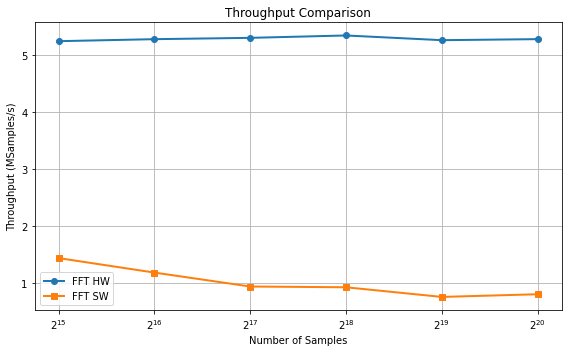

In [21]:
plt.figure(figsize=(8,5))
plt.plot(sizes, throughput_hw, 'o-', linewidth=2, label='FFT HW')
plt.plot(sizes, throughput_sw, 's-', linewidth=2, label='FFT SW')
plt.grid(True)
plt.legend()
plt.xlabel("Number of Samples")
plt.ylabel("Throughput (MSamples/s)")
plt.title("Throughput Comparison")
plt.xscale("log", base=2)
plt.tight_layout()
plt.savefig("Benchmark_Throughput_PS_vs_PL.png", dpi=300)

**Comentario:** curva de *throughput* (MS/s) en función de `N`, en escala logarítmica base 2 en el eje X (coherente con que `sizes` son potencias de 2). Permite observar si el throughput de PL se mantiene aproximadamente constante (dominado por el tamaño de ventana fijo) mientras el de PS varía con la complejidad `O(N log₂N)`.

---

### Celda 6 — Gráfica 2: Comparación de tiempo de ejecución

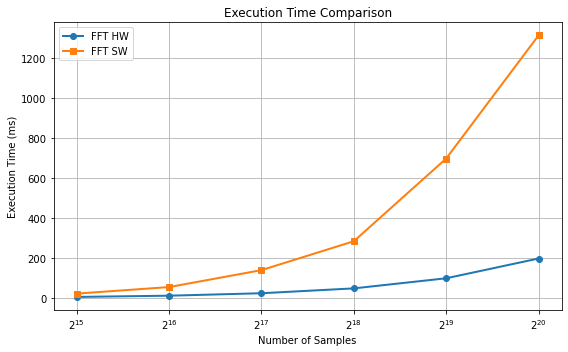

In [22]:
plt.figure(figsize=(8,5))
plt.plot(sizes, time_hw, 'o-', linewidth=2, label='FFT HW')
plt.plot(sizes, time_sw, 's-', linewidth=2, label='FFT SW')
plt.grid(True)
plt.legend()
plt.xlabel("Number of Samples")
plt.ylabel("Execution Time (ms)")
plt.title("Execution Time Comparison")
plt.xscale("log", base=2)
plt.tight_layout()
plt.savefig("Benchmark_Time_PS_vs_PL.png", dpi=300)

**Comentario:** curva de tiempo absoluto de ejecución (ms) para PS y PL en función de `N`. Es la contraparte directa de la gráfica de *throughput* y facilita identificar el punto de cruce (si existe) a partir del cual PL se vuelve más rápido que PS en términos absolutos.

---

### Celda 7 — Gráfica 3: Speedup de hardware

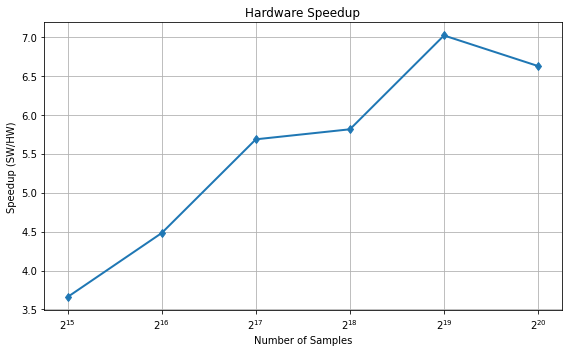

In [23]:
plt.figure(figsize=(8,5))
plt.plot(sizes, speedup, 'd-', linewidth=2)
plt.grid(True)
plt.xlabel("Number of Samples")
plt.ylabel("Speedup (SW/HW)")
plt.title("Hardware Speedup")
plt.xscale("log", base=2)
plt.tight_layout()
plt.savefig("Benchmark_Speedup_PS_vs_PL.png", dpi=300)

plt.show()

**Comentario:** curva de *speedup* = `T_SW(N) / T_HW(N)` en función de `N`. Es la gráfica de síntesis del experimento: valores mayores a 1 indican ventaja de PL sobre PS para ese volumen de datos. `plt.show()` despliega las tres figuras generadas en el notebook (además de guardarlas en disco).

---

### Celda 8 — Tabla resumen de resultados

In [24]:
print("\n==============================================================")
print("                 PS vs PL BENCHMARK")
print("==============================================================")
print("{:^12} {:^12} {:^12} {:^15} {:^15} {:^10}".format(
    "Samples", "HW(ms)", "SW(ms)", "HW(MS/s)", "SW(MS/s)", "Speedup"
))

for i in range(len(sizes)):
    print("{:^12d} {:^12.3f} {:^12.3f} {:^15.2f} {:^15.2f} {:^10.2f}".format(
        sizes[i], time_hw[i], time_sw[i],
        throughput_hw[i], throughput_sw[i], speedup[i]
    ))

print("\nFigures saved in:")
print(os.getcwd())


                 PS vs PL BENCHMARK
  Samples       HW(ms)       SW(ms)       HW(MS/s)        SW(MS/s)      Speedup  
   32768        6.243        22.856         5.25            1.43          3.66   
   65536        12.403       55.592         5.28            1.18          4.48   
   131072       24.697      140.387         5.31            0.93          5.68   
   262144       49.009      284.888         5.35            0.92          5.81   
   524288       99.557      698.627         5.27            0.75          7.02   
  1048576      198.430      1314.522        5.28            0.80          6.62   

Figures saved in:
/home/xilinx/jupyter_notebooks/Banco1_BancoDeRadiofrecuencia/Exp1_EspectrogramaDeWaterfall



**Comentario:** imprime una tabla formateada con todos los resultados numéricos del barrido — insumo directo para la Tabla 2 del informe (§8.1) — e indica la ruta local donde quedaron guardadas las tres figuras (`Benchmark_Throughput_PS_vs_PL.png`, `Benchmark_Time_PS_vs_PL.png`, `Benchmark_Speedup_PS_vs_PL.png`), que deben adjuntarse al reporte de laboratorio.

---

## 8. ANÁLISIS DE RESULTADOS

### 8.1 Tabla comparativa — analizador *waterfall* en vivo (Casos 1 y 2)

Completar con los valores medidos en cada caso:

| Métrica | Caso 1 — PS (`FFT_SIZE=8192`) | Caso 2 — PL (`FFT_SIZE=32768`) |
|---|---|---|
| T_read (ms) | | |
| T_FFT (ms) | | |
| T_waterfall (ms) | | |
| T_total / ToE (ms) | | |
| FPS | | |
| Throughput (MS/s) | | |
| RSSI (dBm) | | |
| SNR (dB) | | |

**Pregunta guiada:** dado que el Caso 1 usa `FFT_SIZE = 8192` y el Caso 2 usa `FFT_SIZE = 32768` (4× más muestras), ¿es válido comparar directamente `T_FFT(PS)` con `T_FFT(PL)` de esta tabla para calcular un *speedup*? Justifique por qué el benchmark formal de la sección 7 fue necesario precisamente para resolver esta limitación.

### 8.2 Tabla y gráficas del benchmark cuantitativo formal (§7)

Completar con la salida de la Celda 8 (§7, tabla resumen) y adjuntar las tres figuras generadas:

| N (muestras) | HW (ms) | SW (ms) | HW (MS/s) | SW (MS/s) | Speedup (SW/HW) |
|---|---|---|---|---|---|
| 32 768 | | | | | |
| 65 536 | | | | | |
| 131 072 | | | | | |
| 262 144 | | | | | |
| 524 288 | | | | | |
| 1 048 576 | | | | | |

- `Benchmark_Throughput_PS_vs_PL.png` — adjuntar.
- `Benchmark_Time_PS_vs_PL.png` — adjuntar.
- `Benchmark_Speedup_PS_vs_PL.png` — adjuntar.

**Preguntas guiadas:**

1. ¿El *speedup* crece, decrece o se mantiene aproximadamente constante a medida que aumenta `N`? Relacione la tendencia observada con las complejidades `O(N log₂N)` (PS) vs. `(N/32768)·O(32768 log₂32768)` (PL) descritas en §7.1.
2. ¿Existe un valor de `N` a partir del cual el tiempo absoluto de PL supera (o dejar de superar) al de PS? Identifique ese punto de cruce, si lo hay, en la gráfica de tiempo de ejecución.
3. El código reserva (`allocate`) y libera (`freebuffer`) los buffers `tx`/`rx` **en cada iteración de `N`**, no en cada ventana `w`. ¿Qué parte del `t_hw` medido corresponde a este *overhead* de gestión de memoria y no al cómputo o la transferencia DMA en sí? ¿Cómo lo aislaría experimentalmente?

### 8.3 Preguntas de análisis adicionales

1. ¿Qué componente del *pipeline* domina el tiempo total (`T_total`) en cada caso del analizador *waterfall*? ¿Cambia el cuello de botella al migrar la FFT al hardware?
2. En el Caso 2 (§6), ¿qué fracción del tiempo de `T_total` corresponde a operaciones que **no** se aceleraron (lectura SDR, conversión Q15, `fftshift`, graficado)? Relacione esto con la Ley de Amdahl.
3. Explique por qué fue necesario fijar `FFT_SIZE_REF_CAL = 8192` de forma independiente al `FFT_SIZE` del bucle principal al calibrar el offset de RSSI.
4. ¿Qué efecto tiene la cuantización a Q15 (16 bits con signo) sobre el rango dinámico y el ruido de cuantización observado en PL, comparado con la precisión de punto flotante (`complex64`/`complex128`) usada en PS?
5. Proponga una modificación del código del benchmark (§7) para medir explícitamente el tiempo de transferencia DMA (`t_dma`) por separado del *overhead* de conversión Q15 y de la reserva/liberación de buffers.
6. A partir del RSSI teórico de Friis calculado y el valor medido tras calibración en la última iteración del *waterfall*, discuta posibles fuentes de discrepancia entre el modelo de espacio libre y las condiciones reales del enlace UTEC–Chorrillos (obstrucciones, multitrayecto, ganancia real de antena, potencia real de transmisión).

---

## 9. CONCLUSIONES ESPERADAS

Al finalizar el experimento, el estudiante debe ser capaz de:

- Cuantificar, con datos propios, el impacto de migrar una etapa de cómputo intensivo (FFT) del procesador a la lógica programable en un SoC Zynq, tanto en un escenario de operación en vivo (*waterfall*) como en un benchmark controlado por barrido de `N`.
- Reconocer las limitaciones prácticas del co-diseño (overhead de conversión de formato, gestión de buffers DMA, precisión numérica) frente al beneficio teórico de paralelismo en hardware.
- Distinguir metodológicamente entre un *speedup* medido sobre tamaños de FFT distintos (no comparable de forma directa) y uno medido sobre un mismo volumen total de muestras `N` con estrategias de partición distintas (comparación válida si se documenta la diferencia algorítmica, como en §7.1).
- Argumentar, con base en la Ley de Amdahl, por qué acelerar solo una etapa del *pipeline* no garantiza una mejora proporcional del sistema completo.
- Aplicar el modelo de Friis como herramienta de calibración para convertir mediciones relativas de un SDR de bajo costo en estimaciones físicas de RSSI.

---

## 10. REFERENCIAS SUGERIDAS

- Xilinx/AMD. *Zynq-7000 SoC Technical Reference Manual.*
- PYNQ Documentation. *pynq.Overlay, pynq.allocate, AXI DMA.* (http://pynq.readthedocs.io)
- Rappaport, T. S. *Wireless Communications: Principles and Practice* (modelo de Friis).
- Oppenheim, A. V.; Schafer, R. W. *Discrete-Time Signal Processing* (FFT y análisis espectral).
- Documentación de `pyrtlsdr`. (https://pyrtlsdr.readthedocs.io)

---

*Guía elaborada para el Banco de Pruebas de Procesamiento de Señales Electromagnéticas — Laboratorio Remoto PYNQ-Z2.*


## 11. PRODUCTO - ANALIZADOR DE ESPECTROS DE TIPO WATERFALL (VERSIÓN PS)
- Se le pide analizar su funcionamiento.

Detenido por el usuario
Mostrando el último espectrograma...


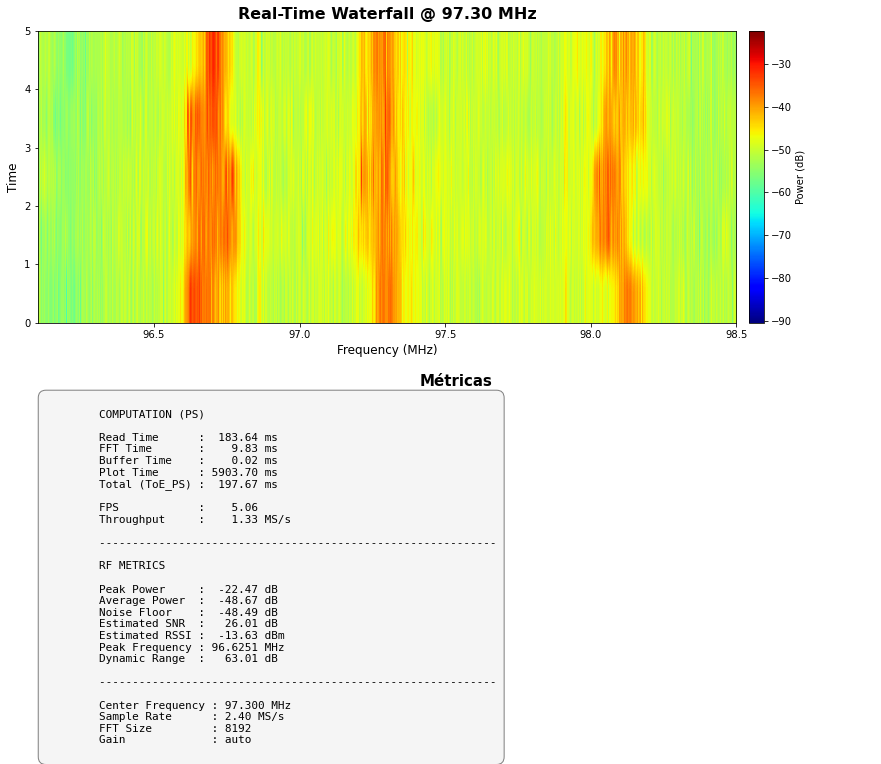

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rtlsdr import RtlSdr
from IPython.display import clear_output
import time
from IPython.display import clear_output, display

# ==========================================================
# CONFIGURACIÓN
# ==========================================================

CENTER_FREQ = 97.3e6
SAMPLE_RATE = 2.4e6
FFT_SIZE = 8192#32768 #65536 #262144 #8192 #1024
GAIN = 'auto'

# ==========================================================
# RSSI — BALANCE DE ENLACE (FRIIS), Radio Moda 97.3 MHz -> UTEC
# ==========================================================
# El RTL-SDR entrega muestras IQ en unidades arbitrarias del ADC,
# no en dBm calibrados. Para reportar un RSSI físico realista, se
# usa el balance de enlace de Friis como referencia de calibración:
#   RSSI(dBm) = Pt - PL + Gt + Gr
#   PL(dB)    = 20log10(d) + 20log10(f) + 20log10(4*pi/c)

LINK_DISTANCE_M = 3800.0    # Jr. Justo Pastor Dávila 197, Chorrillos -> UTEC (~3.8 km)
LIGHT_SPEED_MPS = 3e8

TX_POWER_W = 1000.0         # Potencia de Tx asumida (FM comercial típica). AJUSTAR si se conoce el dato real.
TX_GAIN_DBD = 6.8           # Ganancia de antena Tx asumida (punto medio del rango típico 1.5-12 dBd)
RX_GAIN_DBI = 0.0           # Ganancia antena Rx (Nooelec Smart SDR v5, estimación conservadora)

FFT_SIZE_REF_CAL = 8192     # Tamaño de FFT usado solo durante la calibración inicial del offset RSSI
N_AVG_CAL = 10              # Número de lecturas promediadas para la calibración

# ==========================================================
# INIT RTL-SDR
# ==========================================================

sdr = RtlSdr()
sdr.sample_rate = SAMPLE_RATE
sdr.center_freq = CENTER_FREQ
sdr.gain = GAIN

# ==========================================================
# RSSI — PATH LOSS DE FRIIS Y CALIBRACIÓN DEL OFFSET
# ==========================================================

def friis_path_loss_db(distance_m, freq_hz, c=LIGHT_SPEED_MPS):
    return (20*np.log10(distance_m)
            + 20*np.log10(freq_hz)
            + 20*np.log10(4*np.pi/c))

PATH_LOSS_DB = friis_path_loss_db(LINK_DISTANCE_M, CENTER_FREQ)

# RSSI teórico de referencia (balance de enlace de Friis)
RSSI_THEORETICAL_DBM = (
    10*np.log10(TX_POWER_W*1000.0) - PATH_LOSS_DB + TX_GAIN_DBD + RX_GAIN_DBI
)

# Calibración del offset: se toman unas lecturas reales del SDR
# ANTES de iniciar el loop en vivo, normalizando la potencia por
# FFT_SIZE_REF_CAL (clave para que el offset no dependa del tamaño
# de FFT usado después en el loop), y se ancla ese valor medido al
# RSSI teórico de Friis.
_cal_peaks = []
for _ in range(N_AVG_CAL):
    _samples_cal = sdr.read_samples(256*1024)
    _spectrum_cal = np.fft.fftshift(np.fft.fft(_samples_cal, n=FFT_SIZE_REF_CAL))
    _power_cal = 10*np.log10((np.abs(_spectrum_cal)**2)/(FFT_SIZE_REF_CAL**2) + 1e-12)
    _cal_peaks.append(np.max(_power_cal))

RSSI_CAL_OFFSET_DB = RSSI_THEORETICAL_DBM - np.mean(_cal_peaks)

print(f"[RSSI] Path Loss (Friis): {PATH_LOSS_DB:.2f} dB")
print(f"[RSSI] RSSI teórico de referencia: {RSSI_THEORETICAL_DBM:.2f} dBm")
print(f"[RSSI] Offset de calibración aplicado: {RSSI_CAL_OFFSET_DB:.2f} dB")

# ==========================================================
# WATERFALL
# ==========================================================

waterfall = []

plt.figure(figsize=(14,7))

last_plot_time = 0

last_figure = None
try:

    while True:

        t_total_start = time.perf_counter()

        # ==================================================
        # READ IQ
        # ==================================================

        t0 = time.perf_counter()
        samples = sdr.read_samples(256*1024)
        t_read = time.perf_counter() - t0

        # ==================================================
        # FFT
        # ==================================================

        t0 = time.perf_counter()

        ### INICIO FFT (PUEDE SER DE PS O DE PL) 
        spectrum = np.fft.fftshift(
            np.fft.fft(samples, n=FFT_SIZE)
        )

        power = 10*np.log10(
            (np.abs(spectrum)**2)/(FFT_SIZE**2) + 1e-12
        )
        ### FIN FFT (PUEDE SER DE PS O DE PL)
        t_fft_ps = time.perf_counter() - t0

        # ==================================================
        # RF METRICS
        # ==================================================

        peak_power = np.max(power)

        avg_power = np.mean(power)

        noise_floor = np.median(power)

        snr = peak_power - noise_floor

        peak_index = np.argmax(power)

        freq_axis = np.linspace(
            CENTER_FREQ - SAMPLE_RATE/2,
            CENTER_FREQ + SAMPLE_RATE/2,
            FFT_SIZE
        )

        peak_frequency = freq_axis[peak_index]

        dynamic_range = peak_power - np.min(power)

        # RSSI estimado en vivo: potencia pico (ya normalizada por
        # FFT_SIZE) + offset calibrado contra el balance de enlace
        # de Friis (calculado una sola vez antes del loop).
        rssi_estimated = peak_power + RSSI_CAL_OFFSET_DB

        # ==================================================
        # UPDATE WATERFALL
        # ==================================================

        t0 = time.perf_counter()

        waterfall.append(power)

        if len(waterfall) > 100:
            waterfall.pop(0)

        t_waterfall = time.perf_counter() - t0

        # ==================================================
        # TOTAL TIME
        # ==================================================

        t_total = time.perf_counter() - t_total_start

        fps = 1.0 / t_total

        throughput = len(samples) / t_total / 1e6
        
        
        # ==================================================
        # DISPLAY
        # ==================================================

        t0 = time.perf_counter()

        clear_output(wait=True)

        plt.clf()

        # Figura más grande
        fig = plt.gcf()
        fig.set_size_inches(15, 9)

        # Layout con separación vertical
        gs = fig.add_gridspec(
            nrows=2,
            ncols=1,
            height_ratios=[4.2, 1.8],
            hspace=0.35      # separación entre ambas gráficas
        )

        # ==================================================
        # WATERFALL
        # ==================================================

        ax1 = fig.add_subplot(gs[0])

        im = ax1.imshow(
            waterfall,
            aspect='auto',
            cmap='jet',
            extent=[
                (CENTER_FREQ-SAMPLE_RATE/2)/1e6,
                (CENTER_FREQ+SAMPLE_RATE/2)/1e6,
                0,
                len(waterfall)
            ]
        )

        ax1.set_title(
            f"Real-Time Waterfall @ {CENTER_FREQ/1e6:.2f} MHz",
            fontsize=16,
            fontweight='bold',
            pad=12
        )

        ax1.set_xlabel("Frequency (MHz)", fontsize=12)
        ax1.set_ylabel("Time", fontsize=12)

        cbar = fig.colorbar(
            im,
            ax=ax1,
            pad=0.015
        )

        cbar.set_label("Power (dB)")

        
            
        # ==================================================
        # METRICS
        # ==================================================

        ax2 = fig.add_subplot(gs[1])

        ax2.set_title(
            "Métricas",
            fontsize=15,
            fontweight='bold',
            pad=10
        )

        ax2.axis("off")

        metrics = f"""
        COMPUTATION (PS)

        Read Time      : {t_read*1000:7.2f} ms
        FFT Time       : {t_fft_ps*1000:7.2f} ms
        Buffer Time    : {t_waterfall*1000:7.2f} ms
        Plot Time      : {last_plot_time*1000:7.2f} ms
        Total (ToE_PS) : {t_total*1000:7.2f} ms

        FPS            : {fps:7.2f}
        Throughput     : {throughput:7.2f} MS/s

        ------------------------------------------------------------

        RF METRICS

        Peak Power     : {peak_power:7.2f} dB
        Average Power  : {avg_power:7.2f} dB
        Noise Floor    : {noise_floor:7.2f} dB
        Estimated SNR  : {snr:7.2f} dB
        Estimated RSSI : {rssi_estimated:7.2f} dBm
        Peak Frequency : {peak_frequency/1e6:7.4f} MHz
        Dynamic Range  : {dynamic_range:7.2f} dB

        ------------------------------------------------------------

        Center Frequency : {CENTER_FREQ/1e6:.3f} MHz
        Sample Rate      : {SAMPLE_RATE/1e6:.2f} MS/s
        FFT Size         : {FFT_SIZE}
        Gain             : {GAIN}
        """

        ax2.text(
            0.01,
            0.98,
            metrics,
            va="top",
            ha="left",
            fontsize=11,
            family="monospace",
            bbox=dict(
                facecolor="#F5F5F5",
                edgecolor="gray",
                boxstyle="round,pad=0.7"
            )
        )

        plt.show()

        # Guardar una referencia a la última figura mostrada
        last_figure = plt.gcf()

        last_plot_time = time.perf_counter() - t0
      


        time.sleep(0.05)

except KeyboardInterrupt:

    clear_output(wait=True)

    print("Detenido por el usuario")
    print("Mostrando el último espectrograma...")

    if last_figure is not None:
        display(last_figure)

finally:

    sdr.close()

## 12. PRODUCTO - ANALIZADOR DE ESPECTROS DE TIPO WATERFALL (VERSIÓN PL)
- Se le pide analizar su funcionamiento.

Detenido por el usuario
Mostrando el último espectrograma...


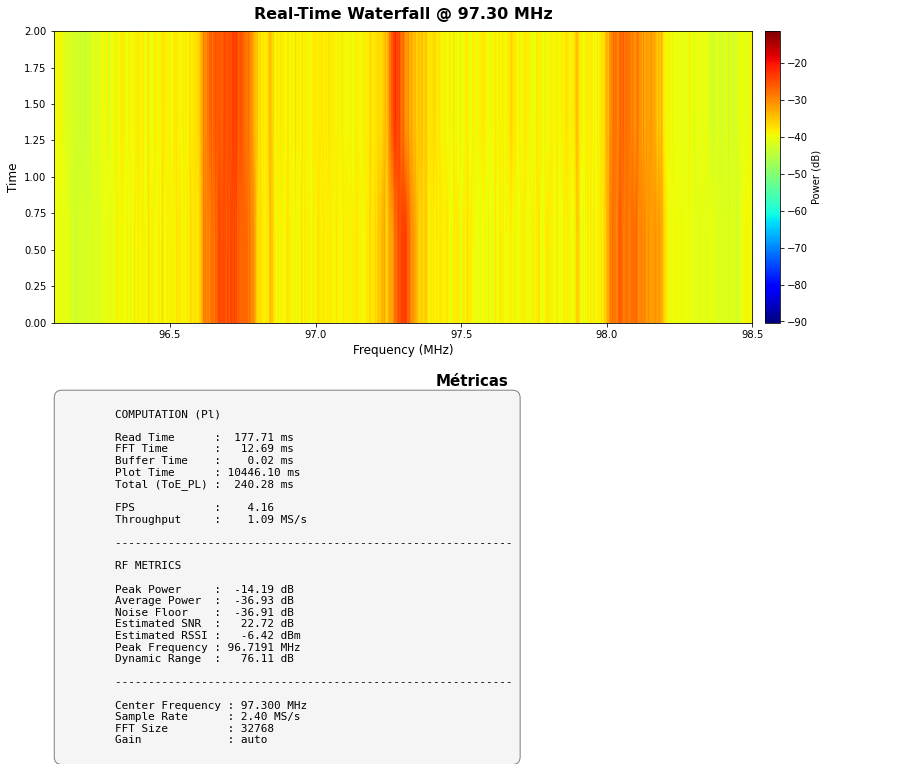

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from rtlsdr import RtlSdr
from IPython.display import clear_output
import time
from pynq import Overlay, allocate
from IPython.display import clear_output, display

# ==========================================================
# CONFIGURACIÓN
# ==========================================================

CENTER_FREQ = 97.3e6
SAMPLE_RATE = 2.4e6
FFT_SIZE = 32768 #65536 #262144 #8192 #1024
GAIN = 'auto'

# ==========================================================
# RSSI — BALANCE DE ENLACE (FRIIS), Radio Moda 97.3 MHz -> UTEC
# ==========================================================
# El RTL-SDR entrega muestras IQ en unidades arbitrarias del ADC,
# no en dBm calibrados. Para reportar un RSSI físico realista, se
# usa el balance de enlace de Friis como referencia de calibración:
#   RSSI(dBm) = Pt - PL + Gt + Gr
#   PL(dB)    = 20log10(d) + 20log10(f) + 20log10(4*pi/c)

LINK_DISTANCE_M = 3800.0    # Jr. Justo Pastor Dávila 197, Chorrillos -> UTEC (~3.8 km)
LIGHT_SPEED_MPS = 3e8

TX_POWER_W = 1000.0         # Potencia de Tx asumida (FM comercial típica). AJUSTAR si se conoce el dato real.
TX_GAIN_DBD = 6.8           # Ganancia de antena Tx asumida (punto medio del rango típico 1.5-12 dBd)
RX_GAIN_DBI = 0.0           # Ganancia antena Rx (Nooelec Smart SDR v5, estimación conservadora)

FFT_SIZE_REF_CAL = 8192     # Tamaño de FFT usado solo durante la calibración inicial del offset RSSI
N_AVG_CAL = 10              # Número de lecturas promediadas para la calibración

# ==========================================================
# INIT RTL-SDR
# ==========================================================

sdr = RtlSdr()
sdr.sample_rate = SAMPLE_RATE
sdr.center_freq = CENTER_FREQ
sdr.gain = GAIN


# ==========================================================
# INIT FPGA
# ==========================================================

ol = Overlay("design_1.bit")

dma = ol.axi_dma_0

# Buffers DMA (se reservan una sola vez)

tx_buffer = allocate(shape=(FFT_SIZE,), dtype=np.uint32)
rx_buffer = allocate(shape=(FFT_SIZE,), dtype=np.uint32)


# ==========================================================
# RSSI — PATH LOSS DE FRIIS Y CALIBRACIÓN DEL OFFSET
# ==========================================================

def friis_path_loss_db(distance_m, freq_hz, c=LIGHT_SPEED_MPS):
    return (20*np.log10(distance_m)
            + 20*np.log10(freq_hz)
            + 20*np.log10(4*np.pi/c))

PATH_LOSS_DB = friis_path_loss_db(LINK_DISTANCE_M, CENTER_FREQ)

# RSSI teórico de referencia (balance de enlace de Friis)
RSSI_THEORETICAL_DBM = (
    10*np.log10(TX_POWER_W*1000.0) - PATH_LOSS_DB + TX_GAIN_DBD + RX_GAIN_DBI
)

# Calibración del offset: se toman unas lecturas reales del SDR
# ANTES de iniciar el loop en vivo, normalizando la potencia por
# FFT_SIZE_REF_CAL (clave para que el offset no dependa del tamaño
# de FFT usado después en el loop), y se ancla ese valor medido al
# RSSI teórico de Friis.
_cal_peaks = []
for _ in range(N_AVG_CAL):
    _samples_cal = sdr.read_samples(256*1024)
    _spectrum_cal = np.fft.fftshift(np.fft.fft(_samples_cal, n=FFT_SIZE_REF_CAL))
    _power_cal = 10*np.log10((np.abs(_spectrum_cal)**2)/(FFT_SIZE_REF_CAL**2) + 1e-12)
    _cal_peaks.append(np.max(_power_cal))

RSSI_CAL_OFFSET_DB = RSSI_THEORETICAL_DBM - np.mean(_cal_peaks)

print(f"[RSSI] Path Loss (Friis): {PATH_LOSS_DB:.2f} dB")
print(f"[RSSI] RSSI teórico de referencia: {RSSI_THEORETICAL_DBM:.2f} dBm")
print(f"[RSSI] Offset de calibración aplicado: {RSSI_CAL_OFFSET_DB:.2f} dB")

# ==========================================================
# WATERFALL
# ==========================================================

waterfall = []

plt.figure(figsize=(14,7))

last_plot_time = 0
last_figure = None
try:

    while True:

        t_total_start = time.perf_counter()

        # ==================================================
        # READ IQ
        # ==================================================

        t0 = time.perf_counter()
        samples = sdr.read_samples(256*1024)
        t_read = time.perf_counter() - t0

        # ==================================================
        # FFT
        # ==================================================

        # ==================================================
        # FFT HARDWARE (PL)
        # ==================================================

        # t0 = time.perf_counter()

        # --------------------------------------------
        # Tomar únicamente FFT_SIZE muestras
        # --------------------------------------------

        samples_fft = samples[:FFT_SIZE]

        # --------------------------------------------
        # Complex64 -> Q15
        # --------------------------------------------

        I = np.int16(np.real(samples_fft) * 32767)

        Q = np.int16(np.imag(samples_fft) * 32767)

        tx_buffer[:] = (
            (Q.astype(np.uint16).astype(np.uint32) << 16)
            |
            I.astype(np.uint16).astype(np.uint32)
        )

        # --------------------------------------------
        # DMA
        # --------------------------------------------

        dma.recvchannel.transfer(rx_buffer)

        dma.sendchannel.transfer(tx_buffer)

        dma.sendchannel.wait()

        dma.recvchannel.wait()

        # --------------------------------------------
        # Reconstrucción
        # --------------------------------------------

        real = (
            (rx_buffer & 0xFFFF)
            .astype(np.uint16)
            .view(np.int16)
        )

        imag = (
            ((rx_buffer >> 16) & 0xFFFF)
            .astype(np.uint16)
            .view(np.int16)
        )

        t0 = time.perf_counter()
        
        spectrum = real.astype(np.float64) + 1j * imag.astype(np.float64)

        # La IP entrega orden natural
        # Para visualizar igual que NumPy:

        spectrum = np.fft.fftshift(spectrum)
        
        t_fft_pl = time.perf_counter() - t0
        # --------------------------------------------
        # Potencia
        # --------------------------------------------

        
        
        power = 10*np.log10(
            (np.abs(spectrum)**2)/(32767.0*32767.0) + 1e-12
        )

       

        # ==================================================
        # RF METRICS
        # ==================================================

        peak_power = np.max(power)

        avg_power = np.mean(power)

        noise_floor = np.median(power)

        snr = peak_power - noise_floor

        peak_index = np.argmax(power)

        freq_axis = np.linspace(
            CENTER_FREQ - SAMPLE_RATE/2,
            CENTER_FREQ + SAMPLE_RATE/2,
            FFT_SIZE
        )

        peak_frequency = freq_axis[peak_index]

        dynamic_range = peak_power - np.min(power)

        # RSSI estimado en vivo: potencia pico (ya normalizada por
        # FFT_SIZE) + offset calibrado contra el balance de enlace
        # de Friis (calculado una sola vez antes del loop).
        rssi_estimated = peak_power + RSSI_CAL_OFFSET_DB

        # ==================================================
        # UPDATE WATERFALL
        # ==================================================

        t0 = time.perf_counter()

        waterfall.append(power)

        if len(waterfall) > 100:
            waterfall.pop(0)

        t_waterfall = time.perf_counter() - t0

        # ==================================================
        # TOTAL TIME
        # ==================================================

        t_total = time.perf_counter() - t_total_start

        fps = 1.0 / t_total

        throughput = len(samples) / t_total / 1e6
        
        
        # ==================================================
        # DISPLAY
        # ==================================================

        t0 = time.perf_counter()

        clear_output(wait=True)

        plt.clf()

        # Figura más grande
        fig = plt.gcf()
        fig.set_size_inches(15, 9)

        # Layout con separación vertical
        gs = fig.add_gridspec(
            nrows=2,
            ncols=1,
            height_ratios=[4.2, 1.8],
            hspace=0.35      # separación entre ambas gráficas
        )

        # ==================================================
        # WATERFALL
        # ==================================================

        ax1 = fig.add_subplot(gs[0])

        im = ax1.imshow(
            waterfall,
            aspect='auto',
            cmap='jet',
            extent=[
                (CENTER_FREQ-SAMPLE_RATE/2)/1e6,
                (CENTER_FREQ+SAMPLE_RATE/2)/1e6,
                0,
                len(waterfall)
            ]
        )

        ax1.set_title(
            f"Real-Time Waterfall @ {CENTER_FREQ/1e6:.2f} MHz",
            fontsize=16,
            fontweight='bold',
            pad=12
        )

        ax1.set_xlabel("Frequency (MHz)", fontsize=12)
        ax1.set_ylabel("Time", fontsize=12)

        cbar = fig.colorbar(
            im,
            ax=ax1,
            pad=0.015
        )

        cbar.set_label("Power (dB)")

        
            
        # ==================================================
        # METRICS
        # ==================================================

        ax2 = fig.add_subplot(gs[1])

        ax2.set_title(
            "Métricas",
            fontsize=15,
            fontweight='bold',
            pad=10
        )

        ax2.axis("off")

        metrics = f"""
        COMPUTATION (Pl)

        Read Time      : {t_read*1000:7.2f} ms
        FFT Time       : {t_fft_pl*1000:7.2f} ms
        Buffer Time    : {t_waterfall*1000:7.2f} ms
        Plot Time      : {last_plot_time*1000:7.2f} ms
        Total (ToE_PL) : {t_total*1000:7.2f} ms

        FPS            : {fps:7.2f}
        Throughput     : {throughput:7.2f} MS/s

        ------------------------------------------------------------

        RF METRICS

        Peak Power     : {peak_power:7.2f} dB
        Average Power  : {avg_power:7.2f} dB
        Noise Floor    : {noise_floor:7.2f} dB
        Estimated SNR  : {snr:7.2f} dB
        Estimated RSSI : {rssi_estimated:7.2f} dBm
        Peak Frequency : {peak_frequency/1e6:7.4f} MHz
        Dynamic Range  : {dynamic_range:7.2f} dB

        ------------------------------------------------------------

        Center Frequency : {CENTER_FREQ/1e6:.3f} MHz
        Sample Rate      : {SAMPLE_RATE/1e6:.2f} MS/s
        FFT Size         : {FFT_SIZE}
        Gain             : {GAIN}
        """

        ax2.text(
            0.01,
            0.98,
            metrics,
            va="top",
            ha="left",
            fontsize=11,
            family="monospace",
            bbox=dict(
                facecolor="#F5F5F5",
                edgecolor="gray",
                boxstyle="round,pad=0.7"
            )
        )

        plt.show()

        # Guardar una referencia a la última figura mostrada
        last_figure = plt.gcf()

        last_plot_time = time.perf_counter() - t0
      


        time.sleep(0.05)

except KeyboardInterrupt:

    clear_output(wait=True)

    print("Detenido por el usuario")
    print("Mostrando el último espectrograma...")

    if last_figure is not None:
        display(last_figure)

finally:
    tx_buffer.freebuffer()
    rx_buffer.freebuffer()

    sdr.close()

## 13. Anexos
### 13.1 Anexo A - fft_power_ip.h



In [ ]:
#ifndef FFT_POWER_IP_H
#define FFT_POWER_IP_H

// ============================================================
// fft_power_ip.h  —  Vitis HLS 2022.2  —  PYNQ-Z2
//
// Interfaz AXI-Stream:
//   S_AXIS_IQ  : entrada  IQ   (128 bits = double re + double im)
//   M_AXIS_PWR : salida power  ( 64 bits = double, valor en dB)
//
// Control:
//   AXI4-Lite  : fft_size, n_samples, ap_ctrl
//
// Flujo típico con AXI DMA:
//   PS-DDR → [AXI DMA MM2S] → S_AXIS_IQ → IP → M_AXIS_PWR
//         → [AXI DMA S2MM] → PS-DDR (HP0, 32 o 64 bit)
// ============================================================

#include <ap_int.h>
#include <ap_axi_sdata.h>    // ap_axiu<W,0,0,0>
#include <hls_stream.h>
#include <complex>
#include <hls_math.h>

// ============================================================
// PARÁMETROS GLOBALES
// ============================================================
#define MAX_FFT_SIZE   262144   // 2^18  (máximo FFT_SIZE reconfigurable)
#define MAX_FFT_LOG2   18
#define INPUT_SAMPLES  262144   // 256*1024 muestras IQ del RTL-SDR

// ============================================================
// TIPOS AXI-STREAM
//
//  Entrada IQ — 128 bits por muestra
//    bits [ 63: 0] = parte real     (IEEE-754 double)
//    bits [127:64] = parte imaginaria (IEEE-754 double)
//    TLAST = 1 en la última muestra del paquete
//
//  Salida Power — 64 bits por bin
//    bits [63:0] = potencia en dB   (IEEE-754 double)
//    TLAST = 1 en el último bin (fft_size - 1)
//
//  Compatibilidad DMA/HP0:
//    - HP0 32 bits: el AXI Interconnect inserta un Data Width
//      Converter 32↔128 y 32↔64 automáticamente en Vivado.
//    - HP0 64 bits: Data Width Converter 64↔128 y 64↔64.
//    - El IP siempre opera a 128b entrada / 64b salida.
// ============================================================
typedef ap_axiu<128, 0, 0, 0>  iq_axis_t;    // S_AXIS_IQ
typedef ap_axiu<64,  0, 0, 0>  pwr_axis_t;   // M_AXIS_PWR

// Tipos internos de cómputo (doble precisión)
typedef std::complex<double>   fft_cpx_t;
typedef double                 power_t;

// ============================================================
// TOP-LEVEL FUNCTION
// ============================================================
void fft_power_top(
    hls::stream<iq_axis_t>  &s_axis_iq,   // AXI-Stream esclavo  (entrada)
    hls::stream<pwr_axis_t> &m_axis_pwr,  // AXI-Stream maestro  (salida)
    unsigned int             fft_size,    // AXI4-Lite — tamaño FFT (pot. de 2)
    unsigned int             n_samples    // AXI4-Lite — muestras a consumir
);

#endif // FFT_POWER_IP_H

### 13.2 Anexo B - fft_power_ip.cpp


In [ ]:
// ============================================================
// fft_power_ip.cpp
// Vitis HLS 2022.2 — PYNQ-Z2
//
// Reemplaza en PL (con AXI-Stream) el bloque Python:
//   spectrum = np.fft.fftshift(np.fft.fft(samples, n=FFT_SIZE))
//   power    = 10*log10((|spectrum|^2)/(FFT_SIZE^2) + 1e-12)
//
// Interfaz de datos:
//   S_AXIS_IQ  (128b) ← AXI DMA MM2S ← PS DDR
//   M_AXIS_PWR  (64b) → AXI DMA S2MM → PS DDR
//
// El puerto HP0 (32 o 64 bit) del Zynq se conecta al DMA;
// Vivado inserta los Data Width Converters automáticamente.
// ============================================================

#include "fft_power_ip.h"
#include <hls_math.h>

#ifndef M_PI
#define M_PI 3.14159265358979323846
#endif

// ============================================================
// MEMORIA INTERNA ON-CHIP (BRAM)
// ============================================================

// Buffer principal de la FFT (in-place, doble precisión)
// NOTA: #pragma HLS BIND_STORAGE debe ir en scope de función,
//       no en scope global. Se declara la variable aquí y el
//       pragma se pone en fft_power_top().
static fft_cpx_t fft_buf[MAX_FFT_SIZE];

// Tabla de twiddle factors W_N^k = exp(-j2πk/N), k=0..N/2-1
static fft_cpx_t twiddle[MAX_FFT_SIZE / 2];

// ============================================================
// UTILIDAD: log2 entero (N potencia de 2)
// ============================================================
static unsigned int ilog2(unsigned int N)
{
#pragma HLS INLINE
    unsigned int r = 0;
    unsigned int t = N;
    while (t > 1) {
#pragma HLS UNROLL factor=18
        t >>= 1;
        r++;
    }
    return r;
}

// ============================================================
// STAGE A — RECEPCIÓN AXI-STREAM → fft_buf[]
//
// Consume exactamente min(n_samples, fft_size) palabras de 128b
// del stream de entrada y rellena con ceros si n_samples < fft_size.
// Cada word de 128b = { im[63:0], re[63:0] } en little-endian
// (orden que genera el driver numpy/PYNQ al empaquetar complex128).
// ============================================================
static void axis_to_buf(
    hls::stream<iq_axis_t> &s_axis_iq,
    unsigned int            fft_size,
    unsigned int            n_samples)
{
#pragma HLS INLINE off

    unsigned int load = (n_samples < fft_size) ? n_samples : fft_size;

    LOAD_STREAM:
    for (unsigned int i = 0; i < MAX_FFT_SIZE; i++) {
#pragma HLS PIPELINE II=1
        if (i >= fft_size) break;

        if (i < load) {
            iq_axis_t word = s_axis_iq.read();

            // Desempaquetar: bits[63:0]=re, bits[127:64]=im
            ap_uint<64> re_bits = word.data(63,  0);
            ap_uint<64> im_bits = word.data(127, 64);

            // Reinterpret as double (bit-cast)
            double re, im;
            *reinterpret_cast<ap_uint<64>*>(&re) = re_bits;
            *reinterpret_cast<ap_uint<64>*>(&im) = im_bits;

            fft_buf[i] = fft_cpx_t(re, im);
        } else {
            // zero-padding: rellenar sin leer del stream
            fft_buf[i] = fft_cpx_t(0.0, 0.0);
        }
    }
}

// ============================================================
// STAGE B — PRECÓMPUTO DE TWIDDLE FACTORS
// W_N^k = exp(-j2πk/N)  para k = 0 .. N/2 - 1
// ============================================================
static void compute_twiddle(unsigned int N)
{
#pragma HLS INLINE off
    TWIDDLE_LOOP:
    for (unsigned int k = 0; k < MAX_FFT_SIZE / 2; k++) {
#pragma HLS PIPELINE II=1
        if (k >= N / 2) break;
        double angle = -2.0 * M_PI * (double)k / (double)N;
        twiddle[k] = fft_cpx_t(hls::cos(angle), hls::sin(angle));
    }
}

// ============================================================
// STAGE C — BIT-REVERSE PERMUTATION
// ============================================================
static void bit_reverse(unsigned int N, unsigned int log2N)
{
#pragma HLS INLINE off
    BIT_REV:
    for (unsigned int i = 0; i < MAX_FFT_SIZE; i++) {
#pragma HLS PIPELINE II=1
        if (i >= N) break;
        unsigned int j   = 0;
        unsigned int tmp = i;
        for (unsigned int b = 0; b < MAX_FFT_LOG2; b++) {
#pragma HLS UNROLL
            j   = (j << 1) | (tmp & 1);
            tmp >>= 1;
        }
        // Descartar bits sobrantes del bit-reverse (sólo log2N bits)
        j >>= (MAX_FFT_LOG2 - log2N);
        if (j > i) {
            fft_cpx_t t = fft_buf[i];
            fft_buf[i]  = fft_buf[j];
            fft_buf[j]  = t;
        }
    }
}

// ============================================================
// STAGE D — FFT RADIX-2 DIT (Cooley-Tukey, in-place)
// ============================================================
static void fft_butterfly(unsigned int N, unsigned int log2N)
{
#pragma HLS INLINE off

    bit_reverse(N, log2N);

    // s = stage: 1 .. log2N
    for (unsigned int s = 1; s <= MAX_FFT_LOG2; s++) {
        if (s > log2N) break;

        unsigned int m        = 1u << s;        // tamaño del sub-DFT
        unsigned int half_m   = m >> 1;
        unsigned int tw_step  = N / m;          // salto en twiddle[]

        BUTTERFLY_K:
        for (unsigned int k = 0; k < MAX_FFT_SIZE; k += m) {
            if (k >= N) break;

            BUTTERFLY_J:
            for (unsigned int j = 0; j < MAX_FFT_SIZE / 2; j++) {
#pragma HLS PIPELINE II=3
                if (j >= half_m) break;

                unsigned int tw_idx = j * tw_step;
                fft_cpx_t W = twiddle[tw_idx];
                fft_cpx_t t = W * fft_buf[k + j + half_m];
                fft_cpx_t u = fft_buf[k + j];

                fft_buf[k + j]          = u + t;
                fft_buf[k + j + half_m] = u - t;
            }
        }
    }
}

// ============================================================
// STAGE E — CÁLCULO DE POTENCIA + FFTSHIFT → M_AXIS_PWR
//
// Salida: out[i] = 10·log10( |fft_buf[(i+N/2)%N]|²/N² + 1e-12 )
// fftshift integrado en el índice de lectura.
// Escribe TLAST=1 en el último bin.
// ============================================================
static void power_fftshift_to_axis(
    hls::stream<pwr_axis_t> &m_axis_pwr,
    unsigned int              N,
    double                    inv_N2)   // 1/(N*N) precalculado
{
#pragma HLS INLINE off

    unsigned int half_N = N >> 1;

    PWR_LOOP:
    for (unsigned int i = 0; i < MAX_FFT_SIZE; i++) {
#pragma HLS PIPELINE II=4
        if (i >= N) break;

        // fftshift: leer desde la mitad superior primero
        unsigned int src = (i < half_N) ? (i + half_N) : (i - half_N);

        fft_cpx_t cpx = fft_buf[src];
        double re  = cpx.real();
        double im  = cpx.imag();
        double mag2 = re * re + im * im;
        double p    = mag2 * inv_N2 + 1e-12;
        double pdb  = 10.0 * hls::log10(p);

        // Empaquetar en word de 64b
        pwr_axis_t out_word;
        ap_uint<64> pdb_bits;
        *reinterpret_cast<double*>(&pdb_bits) = pdb;
        out_word.data  = pdb_bits;
        out_word.keep  = 0xFF;                // 8 bytes válidos
        out_word.strb  = 0xFF;
        out_word.last  = (i == N - 1) ? 1 : 0;  // TLAST en último bin

        m_axis_pwr.write(out_word);
    }
}

// ============================================================
// TOP-LEVEL FUNCTION
// ============================================================
// Interfaces HLS generadas:
//
//   s_axis_iq  → puerto AXI-Stream esclavo  (S_AXIS)
//                TDATA=128b, TKEEP, TSTRB, TLAST
//
//   m_axis_pwr → puerto AXI-Stream maestro  (M_AXIS)
//                TDATA=64b,  TKEEP, TSTRB, TLAST
//
//   fft_size   → registro AXI4-Lite (bundle=control, offset=0x10)
//   n_samples  → registro AXI4-Lite (bundle=control, offset=0x18)
//   return     → ap_ctrl_hs (start/done/idle en control, offset=0x00)
//
// Conexión Vivado recomendada:
//   AXI DMA (MM2S) TDATA 128b → S_AXIS_IQ
//   AXI DMA (S2MM) TDATA  64b ← M_AXIS_PWR
//   AXI DMA AXI Master        → HP0 (32 o 64b con AXI Interconnect)
//   AXI4-Lite control          → GP0 (PS Master)
// ============================================================
void fft_power_top(
    hls::stream<iq_axis_t>  &s_axis_iq,
    hls::stream<pwr_axis_t> &m_axis_pwr,
    unsigned int             fft_size,
    unsigned int             n_samples)
{
// ------------------------------------------------------------------
// DIRECTIVAS DE INTERFAZ
// ------------------------------------------------------------------

// Stream de entrada: AXI-Stream esclavo
#pragma HLS INTERFACE axis port=s_axis_iq  register_mode=both

// Stream de salida: AXI-Stream maestro
#pragma HLS INTERFACE axis port=m_axis_pwr register_mode=both

// Escalares de control: AXI4-Lite
#pragma HLS INTERFACE s_axilite port=fft_size  bundle=control
#pragma HLS INTERFACE s_axilite port=n_samples bundle=control
#pragma HLS INTERFACE s_axilite port=return    bundle=control

// ------------------------------------------------------------------
// BIND_STORAGE para variables estáticas globales compartidas.
// Deben declararse en scope de función (regla de HLS).
// ------------------------------------------------------------------
#pragma HLS BIND_STORAGE variable=fft_buf type=ram_2p impl=bram
#pragma HLS BIND_STORAGE variable=twiddle type=ram_2p impl=bram

    // Clamp y snap a potencia de 2
    unsigned int N = fft_size;
    if (N < 1024)         N = 1024;
    if (N > MAX_FFT_SIZE) N = MAX_FFT_SIZE;
    unsigned int log2N = ilog2(N);
    N = 1u << log2N;   // snap exacto

    unsigned int ns = n_samples;
    if (ns > INPUT_SAMPLES) ns = INPUT_SAMPLES;

    // Stage A: Stream → BRAM
    axis_to_buf(s_axis_iq, N, ns);

    // Stage B: Precómputo de twiddle factors
    compute_twiddle(N);

    // Stage C+D: FFT Radix-2 DIT (bit-reverse + mariposas)
    fft_butterfly(N, log2N);

    // Stage E: Potencia + fftshift → Stream de salida
    double inv_N2 = 1.0 / ((double)N * (double)N);
    power_fftshift_to_axis(m_axis_pwr, N, inv_N2);
}

### 13.3 Anexo C - fft_power_tb.cpp

In [ ]:
// ============================================================
// fft_power_tb.cpp — Testbench AXI-Stream
// Vitis HLS 2022.2  —  C Simulation + Co-Simulation
//
// Genera un tono puro IQ, lo envía por hls::stream<iq_axis_t>,
// recibe power por hls::stream<pwr_axis_t> y verifica:
//   1. El pico está en el bin correcto (fftshift incluido).
//   2. SNR > 40 dB (ruido de cuantización mínimo).
//   3. TLAST llega en el bin fft_size-1.
// ============================================================

#include "fft_power_ip.h"
#include <iostream>
#include <cmath>
#include <cstdio>
#include <cassert>
#include <cstring>

#ifndef M_PI
#define M_PI 3.14159265358979323846
#endif

// ---- Parámetros del test ------------------------------------
#define TEST_FFT_SIZE    8192
#define TEST_N_SAMPLES   262144        // INPUT_SAMPLES
#define TEST_FS          2.4e6         // Hz
#define TEST_TONE_HZ     50000.0       // offset sobre fc

// ---- Buffers ------------------------------------------------
static iq_axis_t   in_stream_buf[INPUT_SAMPLES];
static pwr_axis_t  out_stream_buf[MAX_FFT_SIZE];

// ---- Helpers ------------------------------------------------
// Empaquetar (re, im) → iq_axis_t (128b)
static iq_axis_t pack_iq(double re, double im, bool last)
{
    iq_axis_t w;
    ap_uint<64> re_bits, im_bits;
    memcpy(&re_bits, &re, 8);
    memcpy(&im_bits, &im, 8);
    w.data(63,   0) = re_bits;
    w.data(127, 64) = im_bits;
    w.keep = 0xFFFF;   // 16 bytes válidos
    w.strb = 0xFFFF;
    w.last = last ? 1 : 0;
    return w;
}

// Desempaquetar pwr_axis_t → double
static double unpack_pwr(const pwr_axis_t &w)
{
    double v;
    ap_uint<64> bits = w.data;
    memcpy(&v, &bits, 8);
    return v;
}

// Índice esperado del tono en la salida fftshifted
static int expected_bin(double f_offset, double fs, int N)
{
    int raw = (int)std::round((f_offset / fs) * N);
    raw = ((raw % N) + N) % N;
    return (raw + N / 2) % N;
}

// ============================================================
// main
// ============================================================
int main()
{
    std::cout << "============================================\n"
              << " FFT Power IP — AXI-Stream Testbench\n"
              << " FFT_SIZE  = " << TEST_FFT_SIZE  << "\n"
              << " N_SAMPLES = " << TEST_N_SAMPLES << "\n"
              << " Tone      = " << TEST_TONE_HZ/1e3 << " kHz\n"
              << "============================================\n\n";

    // ----------------------------------------------------------
    // 1. Generar tono IQ y preparar stream de entrada
    // ----------------------------------------------------------
    hls::stream<iq_axis_t>  s_axis_iq("s_axis_iq");
    hls::stream<pwr_axis_t> m_axis_pwr("m_axis_pwr");

    for (int i = 0; i < TEST_N_SAMPLES; i++) {
        double phase = 2.0 * M_PI * TEST_TONE_HZ / TEST_FS * i;
        double re    = std::cos(phase);
        double im    = std::sin(phase);
        bool   last  = (i == TEST_N_SAMPLES - 1);
        s_axis_iq.write(pack_iq(re, im, last));
    }
    std::cout << "[TB] Stream de entrada listo ("
              << TEST_N_SAMPLES << " muestras)\n";

    // ----------------------------------------------------------
    // 2. Llamar al DUT
    // ----------------------------------------------------------
    fft_power_top(
        s_axis_iq,
        m_axis_pwr,
        (unsigned int)TEST_FFT_SIZE,
        (unsigned int)TEST_N_SAMPLES
    );
    std::cout << "[TB] DUT completado\n";

    // ----------------------------------------------------------
    // 3. Leer stream de salida
    // ----------------------------------------------------------
    double  power_out[MAX_FFT_SIZE] = {0};
    int     n_received = 0;
    bool    got_tlast  = false;

    while (!m_axis_pwr.empty()) {
        pwr_axis_t w = m_axis_pwr.read();
        power_out[n_received] = unpack_pwr(w);
        if (w.last) got_tlast = true;
        n_received++;
    }

    std::cout << "[TB] Bins recibidos : " << n_received  << "\n";
    std::cout << "[TB] TLAST recibido : " << (got_tlast ? "SÍ" : "NO") << "\n";

    // ----------------------------------------------------------
    // 4. Verificar pico
    // ----------------------------------------------------------
    int    exp_idx  = expected_bin(TEST_TONE_HZ, TEST_FS, TEST_FFT_SIZE);
    int    peak_idx = 0;
    double peak_val = power_out[0];

    for (int i = 1; i < n_received; i++) {
        if (power_out[i] > peak_val) {
            peak_val = power_out[i];
            peak_idx = i;
        }
    }

    // Noise floor (excluyendo ±5 bins del tono)
    double noise_sum = 0.0; int noise_cnt = 0;
    for (int i = 0; i < n_received; i++) {
        if (std::abs(i - peak_idx) > 5) {
            noise_sum += power_out[i];
            noise_cnt++;
        }
    }
    double noise_floor = (noise_cnt > 0) ? noise_sum / noise_cnt : -200.0;
    double snr         = peak_val - noise_floor;

    std::cout << "\n[TB] Bin esperado  (fftshift) : " << exp_idx  << "\n";
    std::cout << "[TB] Bin del pico             : " << peak_idx  << "\n";
    std::cout << "[TB] Potencia del pico        : " << peak_val  << " dB\n";
    std::cout << "[TB] Noise floor              : " << noise_floor << " dB\n";
    std::cout << "[TB] SNR                      : " << snr       << " dB\n";

    // Espectro alrededor del pico
    std::cout << "\n[TB] Espectro ±10 bins del pico:\n";
    int lo = std::max(0, peak_idx - 10);
    int hi = std::min(n_received - 1, peak_idx + 10);
    for (int i = lo; i <= hi; i++)
        std::printf("  bin[%5d] = %9.3f dB %s\n",
                    i, power_out[i], (i == peak_idx) ? "<-- PICO" : "");

    // ----------------------------------------------------------
    // 5. Criterios de aceptación
    // ----------------------------------------------------------
    bool ok_bins  = (n_received == TEST_FFT_SIZE);
    bool ok_tlast = got_tlast;
    bool ok_peak  = (peak_idx == exp_idx);
    bool ok_snr   = (snr > 40.0);

    std::cout << "\n[TB] Checks:\n";
    std::printf("  Bins correctos : %s  (%d == %d)\n",
                ok_bins  ? "PASS" : "FAIL", n_received, TEST_FFT_SIZE);
    std::printf("  TLAST          : %s\n",  ok_tlast ? "PASS" : "FAIL");
    std::printf("  Bin del pico   : %s  (%d == %d)\n",
                ok_peak  ? "PASS" : "FAIL", peak_idx, exp_idx);
    std::printf("  SNR > 40 dB    : %s  (%.1f dB)\n",
                ok_snr   ? "PASS" : "FAIL", snr);

    bool all_pass = ok_bins && ok_tlast && ok_peak && ok_snr;
    std::cout << "\n[TB] RESULTADO FINAL: " << (all_pass ? "PASS ✓" : "FAIL ✗") << "\n";
    return all_pass ? 0 : 1;
}